# 01 — Language Coverage Exploration

This notebook explains how I arrived at the project's language-code set and how I evaluate the metadata attached to it. The generated language-code table is `language_codes_comprehensive.csv`. When the family review layer has been applied, the reviewed analytical copy is `language_codes_comprehensive_family_reviewed.csv`. I keep those two layers separate because they answer different questions: the first records how the language list was built, while the second records later decisions about how to group those rows for analysis.

The full list combines several infrastructures into one row per language code. Special-purpose non-language codes such as `und` and `zxx` are excluded at build time.

| Source | Role | `cldr_version` / provenance |
|--------|------|-----------------------------|
| **CLDR 48.2** (npm `cldr-core` + `cldr-localenames-full`) | Scripts, directionality, modern-use flag, official status | `'48.2.0'` |
| **LOC ISO 639-2** | ISO 639-1/2 code mappings for individual languages | source flag columns |
| **Wikimedia** | Language code registry for active Wikipedia projects, not the article translations used later | source flag columns |
| **CLDR v45 supplement** | ISO 639-3 languages in CLDR 45 but absent from CLDR 48.2 | `'45'` |
| **SIL ISO 639-3** | English reference names for CLDR codes absent from CLDR's `en/languages.json`; name enrichment only | auxiliary table |

The source-coverage sections below calculate the current row counts from the live CSV. Family hierarchy (§1.4) also begins with CLDR's `languageGroups.json`, which serializes ISO 639-5 family and collection codes such as `ine` for Indo-European, `sem` for Semitic, and `bnt` for Bantu. Both CLDR npm packages are cached locally. For citation, I treat this as Unicode CLDR version 48.2.0, https://github.com/unicode-org/cldr-json.

Every code in the generated CSV has a non-empty value for `language_code`, `language_name`, `family_name`, `family_name_reconciled`, `directionality`, and `sources`. When the reviewed family layer exists, I use `family_name_reconciled_reviewed` and `family_name_analysis` for family-facing summaries without overwriting the generated source-build artifact.

Sections:
- **§1.1 Identifier Layer** - BCP 47 normalization, `langcodes`, Wikimedia/community identifiers, and parsing edge cases
- **§1.2 Source Coverage and Service Support** - source overlap, conceptual build-up, CLDR version provenance, SIL name enrichment, and Google support coverage
- **§1.3 Constructing the Target Set** - filter strategies, expansion steps, non-modern languages, and directionality overrides
- **§1.4 Language Families** - family distribution, family sizes, assignment provenance, and Glottolog reconciliation
- **§1.5 Script and Directionality** - script systems and LTR/RTL structure


### Source provenance: institutional origins and editorial criteria

I use several registries because no single source captures the language list I need. Each registry is maintained by a different kind of institution, and each one makes a different judgment about what counts as a language worth encoding. 

**CLDR 48.2 (Unicode Common Locale Data Repository).** CLDR is maintained by the Unicode Consortium, the same standards body that stewards Unicode and ICU. I use CLDR because it supplies the software-localization metadata this project needs: script, directionality, English display names, local names, official status, and modern-use flags. CLDR is oriented toward languages implemented in operating systems, browsers, programming languages, and applications, so it tends to privilege languages with corporate, governmental, or large volunteer support. In this pipeline CLDR is the strongest source for script and directionality, but it is not a complete inventory of language communities.

**CLDR v45 supplement.** The supplement is not a separate institution. It is a retained snapshot of codes that appeared in CLDR 45 and were later absent from CLDR 48.2. I initially used CLDR 45 without realizing there was a newer version available, and I kept those rows because CLDR removal reflects locale-maintenance requirements, not a linguistic judgment that a language is irrelevant or unusable. A community may not maintain CLDR Core data and still matter for translation analysis. The supplement therefore lets me treat CLDR as a moving infrastructure rather than as a fixed standard.

**LOC ISO 639-2.** I use the Library of Congress ISO 639-2 data as a bibliographic authority layer. ISO 639-2 is conservative and cataloging-oriented: it represents languages that have had enough published or archival presence to enter library metadata systems. It also preserves the bibliographic and terminological split for languages such as German (`ger`/`deu`), French (`fre`/`fra`), and Chinese (`chi`/`zho`). I record both forms because library history is part of the infrastructure I am trying to keep visible.

**Wikimedia.** Wikimedia gives me a different kind of evidence: an active public writing community. A Wikipedia language edition is not the same as ISO recognition or CLDR locale support. It indicates that a group of editors has built and sustained a language project inside Wikimedia's own approval process. That is why I preserve Wikimedia-specific identifiers such as `zh-min-nan`, `be-x-old`, `roa-rup`, and `tokipona` as source evidence, even when BCP 47 or ISO now offers a different preferred tag. Later notebooks use Wikipedia article content as a translation reference, but here Wikimedia is first of all a language-code source.

**CLDR `languageGroups.json` (ISO 639-5).** I use CLDR's copy of the ISO 639-5 family hierarchy as the starting point for `family_name`. This is a useful administrative vocabulary, but it is not a clean genealogical classification. ISO 639-5 mixes language families with geographic groupings, collection codes, and older macrofamilies. Section 1.4 is therefore built around checking this starting layer against Glottolog rather than assuming the ISO family label is analytically final.

**SIL ISO 639-3 (auxiliary; name enrichment only).** SIL is the ISO 639-3 Registration Authority, and ISO 639-3 is far broader than this project's language set. I do not use SIL to add every ISO 639-3 language. That would change the unit of analysis and expand the dataset by thousands of rows. I use SIL only to fill English display names for codes that are already present through CLDR, LOC, Wikimedia, or the CLDR v45 supplement but missing from CLDR's English name table.

**Glottolog 5.3 (auxiliary; family reconciliation only).** I use Glottolog as an external comparison point for family classification, not as a source of additional language rows. Its value here is that it reflects current genealogical classification more directly than ISO 639-5. The disagreements between Glottolog and ISO 639-5 are not just cleanup tasks; they show where administrative and linguistic infrastructures diverge.

**IANA Language Subtag Registry (auxiliary; BCP 47 canonicalization only).** The BCP 47 layer comes through `langcodes` and `language_data`, which ship a snapshot of the IANA Language Subtag Registry. I use this layer to document how each project row maps into web and API language-tag conventions. I do not use it to replace the project row identifier. A canonical BCP 47 tag is useful for interoperability, but it can also collapse a community identifier into a broader or politically different code.

**Why this matters for the analysis.** I treat these registries as evidence from different institutions, not as interchangeable lists. CLDR tells me what software platforms have reason to localize; ISO 639-2 tells me what libraries catalog; Wikimedia tells me what communities have organized enough public writing to sustain a Wikipedia; SIL tells me how ISO 639-3 names many smaller or endangered languages; Glottolog tells me how linguists classify genealogical relationships; IANA tells me how web infrastructure expects identifiers to be written. Recording which sources attest each row lets me ask which languages are supported across many infrastructures and which appear only in one.


In [1]:
import json
import os
import re
import sys
from collections import Counter, defaultdict
from pathlib import Path

import altair as alt
import langcodes
import langcodes.data_dicts as ld_dicts
import language_data
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
from language_data.population_data import LANGUAGE_SPEAKING_POPULATION
from matplotlib_venn import venn3
from rich import box
from rich.console import Console
from rich.table import Table

sys.path.insert(0, str(Path("..").resolve()))
from scripts.utils import get_data_directory_path

DATA_DIR = get_data_directory_path()
METADATA_DIR = Path(DATA_DIR) / "metadata_files"
BASE_CSV_PATH = METADATA_DIR / "language_codes_comprehensive.csv"
REVIEWED_FAMILY_CSV_PATH = METADATA_DIR / "language_codes_comprehensive_family_reviewed.csv"
CSV_PATH = str(BASE_CSV_PATH)

# converters preserves 'nan' (Min Nan Chinese, ISO 639-3) as a string.
# df is intentionally the generated source-build artifact used for row/source provenance.
df = pd.read_csv(BASE_CSV_PATH, converters={'language_code': str})

# df_reviewed is the post-build family-review layer used for family-facing charts when present.
if REVIEWED_FAMILY_CSV_PATH.exists():
    df_reviewed = pd.read_csv(REVIEWED_FAMILY_CSV_PATH, converters={'language_code': str})
    family_metadata_source = REVIEWED_FAMILY_CSV_PATH.name
else:
    df_reviewed = df.copy()
    family_metadata_source = BASE_CSV_PATH.name

family_analysis_col = "family_name_analysis" if "family_name_analysis" in df_reviewed.columns else "family_name_reconciled"
family_reconciled_col = (
    "family_name_reconciled_reviewed"
    if "family_name_reconciled_reviewed" in df_reviewed.columns
    else "family_name_reconciled"
)

# n_languages is the single source of truth for the target set size used throughout this notebook.
n_languages = df["language_code"].nunique()
print(f"Total languages: {n_languages} unique codes ({len(df)} rows)")
print(f"Generated metadata: {BASE_CSV_PATH.name}")
print(f"Family analysis metadata: {family_metadata_source} ({family_analysis_col})")
print(f"Columns: {list(df.columns)}")

Retrieving translation pipeline data directory path...

Total languages: 881 unique codes (881 rows)
Generated metadata: language_codes_comprehensive.csv
Family analysis metadata: language_codes_comprehensive_family_reviewed.csv (family_name_analysis)
Columns: ['language_code', 'language_name', 'local_name', 'iso639_1', 'iso639_2_t', 'iso639_2_b', 'scripts', 'script_codes', 'primary_script', 'primary_script_code', 'directionality', 'directionality_wikimedia', 'modern_language', 'is_official', 'n_scripts', 'in_iso639_1', 'in_iso639_2', 'in_wikimedia', 'is_group_iso639_2', 'sources', 'cldr_version', 'iso639_5_direct', 'iso639_5_family', 'family_name', 'subfamily_name', 'family_name_reconciled', 'coding_dh_date_added', 'coding_dh_date_last_seen', 'project_language_code', 'wikimedia_code', 'bcp47_tag', 'bcp47_source', 'bcp47_note', 'bcp47_is_project_code', 'service_code_candidates', 'google_nmt_code', 'google_nmt_supported', 'google_translation_llm_code', 'google_translation_llm_supported']


In [2]:
# Live snapshot of the dataset at this moment of running the notebook
n_modern  = df['modern_language'].astype(str).eq('True').sum()
n_rtl     = df['directionality'].eq('rtl').sum()
n_iso1    = df['in_iso639_1'].astype(str).eq('True').sum()
n_iso2    = df['in_iso639_2'].astype(str).eq('True').sum()
n_wiki    = df['in_wikimedia'].astype(str).eq('True').sum()
n_nmt     = df['google_nmt_supported'].astype(str).eq('True').sum()             if 'google_nmt_supported'             in df.columns else 0
n_llm     = df['google_translation_llm_supported'].astype(str).eq('True').sum() if 'google_translation_llm_supported' in df.columns else 0
earliest  = df['coding_dh_date_added'].min()      if 'coding_dh_date_added'     in df.columns else '\u2014'
latest    = df['coding_dh_date_added'].max()      if 'coding_dh_date_added'     in df.columns else '\u2014'
last_seen = df['coding_dh_date_last_seen'].max()  if 'coding_dh_date_last_seen' in df.columns else '\u2014'

snapshot = Table(
    title='Live snapshot of the dataset',
    title_style='bold cyan',
    box=box.ROUNDED,
    show_header=False,
    pad_edge=False,
)
snapshot.add_column('Metric', style='dim', no_wrap=True)
snapshot.add_column('Value', style='bold green', justify='right')
snapshot.add_row('Language codes',                              f'{len(df):,}')
snapshot.add_row('Columns',                                     f'{len(df.columns)}')
snapshot.add_row('Modern languages (CLDR vitality flag)',       f'{n_modern:,}')
snapshot.add_row('RTL languages',                               f'{n_rtl:,}')
snapshot.add_row('In ISO 639-1 (have a 2-letter code)',         f'{n_iso1:,}')
snapshot.add_row('In ISO 639-2 (LOC bibliographic list)',       f'{n_iso2:,}')
snapshot.add_row('In Wikimedia (active Wikipedia project)',     f'{n_wiki:,}')
snapshot.add_row('Google NMT supported',                        f'{n_nmt:,}')
snapshot.add_row('Google Translation LLM supported',            f'{n_llm:,}')
snapshot.add_row('Earliest coding_dh_date_added',               str(earliest))
snapshot.add_row('Most recent coding_dh_date_added',            str(latest))
snapshot.add_row('Most recent coding_dh_date_last_seen',        str(last_seen))

rich_console = Console()
rich_console.print(snapshot)
rich_console.print()
rich_console.print(
    'These numbers are derived from the CSV on disk right now \u2014 every other count in this notebook\n'
    'that is expressed as text rather than as a code-cell output should be read with this snapshot\n'
    'as the reference.',
    style='italic dim',
)


             Live snapshot of the dataset             
╭────────────────────────────────────────┬───────────╮
│Language codes                          │        881│
│Columns                                 │         39│
│Modern languages (CLDR vitality flag)   │        856│
│RTL languages                           │         79│
│In ISO 639-1 (have a 2-letter code)     │        187│
│In ISO 639-2 (LOC bibliographic list)   │        416│
│In Wikimedia (active Wikipedia project) │        270│
│Google NMT supported                    │        184│
│Google Translation LLM supported        │         87│
│Earliest coding_dh_date_added           │ 2026-04-22│
│Most recent coding_dh_date_added        │ 2026-06-15│
│Most recent coding_dh_date_last_seen    │ 2026-06-15│
╰────────────────────────────────────────┴───────────╯

These numbers are derived from the CSV on disk right now — every other count in this notebook
that is expressed as text rather than as a code-cell output should be read with this snapshot
as the reference.

## 1.1 Identifier Layer

Before I count coverage, I need to know what kind of identifier each row represents. This section records the distinction between project/community codes and BCP 47 interoperability tags, compares the dataset with `langcodes`, and collects the edge cases that would be easy to erase through normalization.


### Counterpoint: comparison with `python-langcodes`

A reasonable alternative would have been to start from [`langcodes`](https://github.com/georgkrause/langcodes), which validates language tags against the IANA Language Subtag Registry. I added this comparison because it shows what the project would look like if I began from tag validity rather than from institutional attestation.

The difference is conceptual. `langcodes` answers: is this a well-formed or recognized BCP 47 language subtag? My pipeline answers: which language communities are visible across the infrastructures I can actually use for localization metadata, bibliographic metadata, community publishing, translation services, and search? Those questions produce very different counts. `langcodes` covers a much larger IANA universe, while the pipeline keeps a smaller but more operationally grounded set of rows enriched with scripts, directionality, family labels, Wikimedia evidence, BCP 47 mappings, and service-support flags.


In [3]:
# Compare with python-langcodes (built on the IANA Language Subtag Registry)
# langcodes validates against the IANA registry shipped in language_data
reg_path = Path(language_data.__file__).parent / 'data' / 'language-subtag-registry.txt'
records = reg_path.read_text().split('%%\n')

type_counts = Counter()
deprecated_counts = Counter()
for r in records:
    m = re.search(r'^Type:\s*(\S+)', r, re.M)
    if not m:
        continue
    t = m.group(1)
    type_counts[t] += 1
    if re.search(r'^Deprecated:', r, re.M):
        deprecated_counts[t] += 1

file_date_match = re.search(r'^File-Date:\s*(\S+)', records[0], re.M)
file_date = file_date_match.group(1) if file_date_match else '?'

print(f"IANA Language Subtag Registry (shipped with langcodes / language_data)")
print(f"  Snapshot date: {file_date}")
print(f"  Total subtag records: {sum(type_counts.values())}")
print()
print(f"  {'type':<16} {'total':>6}  {'active':>7}  {'deprecated':>11}")
print(f"  {'-'*16} {'-'*6}  {'-'*7}  {'-'*11}")
for t, total in type_counts.most_common():
    dep = deprecated_counts.get(t, 0)
    print(f"  {t:<16} {total:>6}  {total - dep:>7}  {dep:>11}")

lang_active = type_counts['language'] - deprecated_counts['language']
lang_dep    = deprecated_counts['language']
print()
print(f"  Active 'language' subtags (the closest counterpart to our project codes): {lang_active}")
print(f"  Deprecated 'language' subtags (kept for backwards-compat parsing):         {lang_dep}")
print()

print('-' * 72)
print(f"This pipeline: {len(df)} language codes (see Source provenance above).")
print(f"Ratio: langcodes carries ~{lang_active / len(df):.1f}\u00d7 more language subtags than the pipeline includes.")
print(f"The bulk of that gap is ISO 639-3 codes for speech varieties that no institutional implementation") 
print(f"(CLDR locale, LOC catalog entry, or active Wikipedia) currently exists for.") 
print(f"langcodes will validate them as well-formed tags; the pipeline excludes them because they have no metadata to attach") 
print(f"(no script, directionality, modern-use flag, family classification, or service support to record).")


IANA Language Subtag Registry (shipped with langcodes / language_data)
  Snapshot date: 2021-08-06
  Total subtag records: 9172

  type              total   active   deprecated
  ---------------- ------  -------  -----------
  language           8213     8010          203
  region              304      293           11
  extlang             245      241            4
  script              209      209            0
  variant             108      105            3
  redundant            67       42           25
  grandfathered        26        2           24

  Active 'language' subtags (the closest counterpart to our project codes): 8010
  Deprecated 'language' subtags (kept for backwards-compat parsing):         203

------------------------------------------------------------------------
This pipeline: 881 language codes (see Source provenance above).
Ratio: langcodes carries ~9.1× more language subtags than the pipeline includes.
The bulk of that gap is ISO 639-3 codes for speech varie

#### Adopting `langcodes` for tag canonicalization

I added the `langcodes` comparison late, after much of the language list already existed. That late addition was useful because it showed that I had been maintaining some BCP 47 logic by hand even though a better library already existed. I therefore refactored the identifier layer to use `langcodes` for canonicalization while keeping the original language set intact.

**What changed in `scripts/experiment/generate_language_codes.py`.** The older project-local canonicalizer now delegates to `langcodes.standardize_tag`, which validates against the IANA registry snapshot shipped with `language_data`. I removed the hand-maintained deprecated-subtag table because `langcodes` already knows Preferred-Value rewrites such as `iw` -> `he`, `jw` -> `jv`, and `mo` -> `ro`. The remaining manual fallback list is narrower and covers project-specific Wikimedia/community identifiers that this `language_data` snapshot cannot resolve.

**What did not change.** The refactor did not change the language set or the analytical unit. `language_code` remains the stable row identifier, and the CLDR, LOC, Wikimedia, CLDR v45, ISO 639-5, Glottolog, and service-support layers still operate on that row. `langcodes` replaced one bounded implementation detail: how I record an interoperability tag for a row that is already in the dataset.

**What changed in the CSV.** A few rows now show IANA's official preferred form in `bcp47_tag`, including `cnr` -> `sr-ME`, `sh` -> `sr-Latn`, and `tl` -> `fil`. I keep the original project codes because those rows still represent the source-attested identifiers used by the project. The BCP 47 column documents what an IANA-compliant downstream system would expect; it does not rename the row.

**Methodological consequence.** This revision made the source roles cleaner. CLDR supplies locale metadata, LOC supplies ISO 639-1/2 mappings, Wikimedia supplies community project identifiers, ISO 639-5 and Glottolog support family classification, and `langcodes` supplies BCP 47 normalization. As the IANA snapshot in `language_data` changes, the manual fallback list should shrink, but the project language set should not automatically expand just because a tag is valid.

Implementation note: regenerating the CSV during this refactor exposed a pre-existing bug in `bcp47_is_project_code`. The flag compared against the canonicalized code rather than the raw project code, which made some grandfathered tags look as though they had not changed. Making canonicalization consistent made the bug visible.


#### Paths not taken: could I have built the language set from `langcodes` directly?

The short answer is no, at least not for the question this project asks. `langcodes` and `language_data` can tell me what IANA validates and what CLDR has speaker-population data for. They do not tell me whether a language has an active Wikipedia, whether it appears in LOC's bibliographic code set, or whether it entered this project through an older CLDR version.

The counterfactual counts below are still useful. They show that the pipeline is much smaller than the full IANA universe but larger than many `langcodes` population-threshold subsets. That is the point: I am not trying to enumerate every possible language, dialect, locale, or subtag. I am building a research apparatus for languages that have enough institutional implementation to be searchable, translatable, or verifiable across the systems this project studies.


In [4]:
# Counterfactual: what would 'how many languages?' be under different langcodes-derived filters?
# Sum speaker population across regional variants to get a per-language total
speak_sum = defaultdict(int)
for tag, pop in LANGUAGE_SPEAKING_POPULATION.items():
    speak_sum[tag.split('-')[0]] += pop

rows = [
    ('All active IANA language subtags',
     'Everything langcodes would validate as a well-formed primary language subtag (the full IANA-registry universe — includes endangered, historic, and constructed langs)',
     8010),
    ('Macrolanguage member subtags',
     'Sub-varieties that langcodes considers part of a macrolanguage (e.g. "cmn" inside "zh")',
     len(ld_dicts.MACROLANGUAGES)),
    ('Languages with any CLDR speaker data',
     'Has at least one nonzero entry in language_data.LANGUAGE_SPEAKING_POPULATION (CLDR territoryInfo-derived)',
     len(speak_sum)),
    ('Population \u2265 1,000 speakers (langcodes data)',
     'Sum of speakers across all CLDR territories \u2265 1K',
     sum(1 for v in speak_sum.values() if v >= 1_000)),
    ('Population \u2265 100,000 speakers',
     'Sum of speakers \u2265 100K — roughly the threshold most language-tech catalogues use',
     sum(1 for v in speak_sum.values() if v >= 100_000)),
    ('Population \u2265 1M speakers',
     'Sum of speakers \u2265 1M',
     sum(1 for v in speak_sum.values() if v >= 1_000_000)),
    ('Population \u2265 10M speakers',
     'Sum of speakers \u2265 10M',
     sum(1 for v in speak_sum.values() if v >= 10_000_000)),
    ('ISO 639-1 only (two-letter primary subtags)',
     'The 194 languages with a two-letter code — the conservative \"major languages\" cut',
     len(ld_dicts.LANGUAGE_ALPHA3)),
    ('\u2192  This pipeline (institutional union)',
     'CLDR 48.2 \u222a LOC ISO 639-2 \u222a Wikimedia \u222a CLDR v45 supplement, minus non-language codes',
     len(df)),
]

alt_counts = pd.DataFrame(rows, columns=['approach', 'what it answers', 'count'])
alt_counts['vs_pipeline'] = alt_counts['count'] - len(df)
alt_counts['vs_pipeline'] = alt_counts['vs_pipeline'].apply(
    lambda d: f'{d:+,}' if d != 0 else '\u2014 (this row)'
)

print("Alternative 'how many languages?' counts from langcodes / language_data:")
print()
for _, r in alt_counts.iterrows():
    print(f"  {r['approach']}")
    print(f"      {r['what it answers']}")
    print(f"      count = {r['count']:>5}   vs pipeline ({len(df)}) = {r['vs_pipeline']}")
    print()

# The methodological punchline
print('-' * 72)
print('None of these reproduce the pipeline count. The closest by raw count is "any CLDR speaker')
print(f'data" ({len(speak_sum)}), but it omits {len(df) - len(speak_sum)} languages')
print('the pipeline keeps because they have')
print('Wikimedia presence or CLDR-v45 historical presence without modern speaker')
print('data, and includes languages the pipeline excludes because they lack the')
print('institutional implementations tracked here.')


Alternative 'how many languages?' counts from langcodes / language_data:

  All active IANA language subtags
      Everything langcodes would validate as a well-formed primary language subtag (the full IANA-registry universe — includes endangered, historic, and constructed langs)
      count =  8010   vs pipeline (881) = +7,129

  Macrolanguage member subtags
      Sub-varieties that langcodes considers part of a macrolanguage (e.g. "cmn" inside "zh")
      count =   447   vs pipeline (881) = -434

  Languages with any CLDR speaker data
      Has at least one nonzero entry in language_data.LANGUAGE_SPEAKING_POPULATION (CLDR territoryInfo-derived)
      count =   696   vs pipeline (881) = -185

  Population ≥ 1,000 speakers (langcodes data)
      Sum of speakers across all CLDR territories ≥ 1K
      count =   669   vs pipeline (881) = -212

  Population ≥ 100,000 speakers
      Sum of speakers ≥ 100K — roughly the threshold most language-tech catalogues use
      count =   559   vs pip

#### Checking the BCP 47 Layer

After adding `langcodes`, I ran a small check to see whether the new `bcp47_tag` column mattered operationally. The question was simple: when the project’s `language_code` differed from the IANA-preferred BCP 47 form, would Google Translate return a different result? To test this, I queried Google Translate’s v2 API for the term “Digital Humanities” using both forms for the thirteen rows where `bcp47_tag` substantively differed from `language_code`, excluding differences that only reflected hyphenation or capitalization. The results are stored in `bcp47_spotcheck_results.csv`.

The check found no divergences in the five cases where Google accepted both identifiers. Tagalog/Filipino (`tl`/`fil`), Moldovan/Romanian (`mo`/`ro`), Serbo-Croatian/Serbian Latin (`sh`/`sr-Latn`), Belarusian Taraškievica (`be-x-old`/`be-tarask`), and Cantonese (`zh-yue`/`yue`) all returned identical translations. For these rows, the BCP 47 tag did not provide an alternative translation path. It documented the preferred interoperability form, but querying Google under the project’s source identifier did not change the output.

The failures were more revealing. Montenegrin (`cnr`) was unsupported under both the project identifier and its IANA-preferred form, `sr-ME`. This is a useful example of the institutional-implementation gap the pipeline is designed to study: Montenegrin is visible across several language infrastructures, including CLDR, ISO, Wikimedia, and IANA, but Google Translate provides no model for it under either identifier. Banyumasan (`map-bms`) showed a different problem. The BCP 47 fallback maps it to `jv`, which Google accepts as Javanese, but a Javanese translation is not the same as a Banyumasan translation. For the purposes of this project, the failure of `map-bms` is therefore more informative than the success of `jv`: it records the absence of Banyumasan support rather than hiding that absence behind a broader fallback. Min Nan Chinese exposed a third kind of inconsistency. The preferred tag `nan` appears in Google’s newer supported-language manifest, but the v2 API rejected it. This means the pipeline’s service-support flags, which are derived from the v3 manifest, are accurate for that endpoint but slightly optimistic relative to the v2 translation calls used in the original workflow.

For these reasons, I did not update `language_codes_comprehensive.csv` based on the spot-check. Where Google accepted both forms, the translations were identical. Where both forms failed, the existing unsupported status was already accurate. And where only the BCP 47 fallback succeeded, as with Banyumasan to Javanese, accepting the fallback would have obscured the very support gap the pipeline needed to preserve.

I also did not rerun the LLM prompts under the BCP 47 forms. The reason is that the LLM prompts use the language name, not just the code, and many politically or socially meaningful distinctions already exist as separate rows in the dataset. Tagalog and Filipino, Moldovan and Romanian, Min Nan and `zh-min-nan`, Cantonese and `zh-yue`, Toki Pona and `tokipona`, Aromanian and `roa-rup`, and similar pairs already receive their own prompts under their own language names. Rerunning one row under the other’s preferred tag would not add a new language community; it would duplicate an existing row under the wrong identifier.

The remaining cases are script or region variants, such as `sh` to `sr-Latn`, `cnr` to `sr-ME`, and `be-x-old` to `be-tarask`. These are exactly the kinds of BCP 47 locale distinctions the project intentionally does not expand into. The unit of analysis is language-community discovery, not locale-specific localization within already represented languages. The spot-check therefore confirmed the role of the BCP 47 column: it is an interoperability and documentation layer, not a replacement for the project’s source-attested `language_code` field.

The next two subsections spell out why that distinction has to be preserved in code, not just described in prose. Min Nan shows how a valid language identifier can be erased by ordinary data-processing defaults. The Wikimedia-only rows show the complementary problem: a community identifier can be normalized into a technically valid tag while losing the source-specific evidence that made the row important in the first place.


In [5]:
# Read the committed spot-check results and re-derive the outcome distribution
spot_path = Path('..') / 'datasets' / 'metadata_files' / 'bcp47_spotcheck_results.csv'
spot = pd.read_csv(spot_path, dtype=str, na_filter=False)

print(f'BCP 47 normalization spot-check — {len(spot)} rows tested')
print(f'Source: {spot_path}')
print()
print('Outcome distribution:')
for outcome, n in spot['outcome'].value_counts().items():
    print(f'  {outcome:<16} {n}')
print()

# Show per-row results with the actual translations for the cases that succeeded
display_cols = ['language_code', 'language_name', 'bcp47_tag', 'kind', 'outcome',
                'project_translation', 'bcp47_translation']
display_df = spot[display_cols].copy()
for col in ['project_translation', 'bcp47_translation']:
    display_df[col] = display_df[col].str.slice(0, 30)
print(display_df.to_string(index=False))


BCP 47 normalization spot-check — 13 rows tested
Source: ../datasets/metadata_files/bcp47_spotcheck_results.csv

Outcome distribution:
  both_failed      7
  agree            5
  bcp47_only       1

language_code             language_name bcp47_tag                 kind     outcome          project_translation            bcp47_translation
      bat-smg                Samogitian       sgs        grandfathered both_failed                                                          
     be-x-old Belarusian (Taraškievica) be-tarask        grandfathered       agree Лічбавыя гуманітарныя навукі Лічбавыя гуманітарныя навукі
          cnr               Montenegrin     sr-ME iana_preferred_value both_failed                                                          
      fiu-vro                      Võro       vro        grandfathered both_failed                                                          
      map-bms                Banyumasan        jv        grandfathered  bcp47_only              

### The `nan` edge case: Min Nan Chinese

The BCP 47 check above makes Min Nan look like an ordinary identifier-mapping case: Wikimedia uses `zh-min-nan`, while the preferred ISO/IANA-style code is `nan`. But `nan` creates a second, more mundane problem inside the data pipeline. It is a valid ISO 639-3 language code and also the string many data libraries use for missing numeric values, "Not a Number."

That collision matters because the project relies on code-keyed joins. If I read the metadata CSV without an explicit string converter, pandas can silently turn the language code `nan` into a missing value. A real language then disappears from lookups, family assignment, and review summaries without producing an obvious error.

I guard against this in two places. First, `load_language_codes()` reads the CSV with `converters={'language_code': str}` so the string `nan` stays intact. Second, the family-evidence helper normalizes a pandas missing value back to the string `nan` before lookup. `nan` is also in `MANUAL_LANG_TO_SET5`, mapped through Sinitic to Sino-Tibetan, so it is no longer treated as unassigned.

I keep this edge case in the identifier section because it shows that normalization is not only a standards problem. Sometimes the risk comes from software defaults that have no knowledge of language infrastructure at all.


### Wikimedia-only language codes

The BCP 47 layer also clarifies why I keep Wikimedia identifiers as project row codes even when a preferred tag exists. Languages that appear in Wikimedia but not CLDR are not all the same kind of exception. They show several different identifier problems that I want the dataset to preserve rather than smooth away.

- **Wikimedia-specific or legacy community identifiers** (`bat-smg`, `be-x-old`, `fiu-vro`, `map-bms`, `nds-nl`, `roa-rup`, `zh-classical`, `zh-min-nan`, `zh-tw`, `zh-yue`, `uz_AF`): these are community tags used by Wikipedia projects. Some now map to BCP 47 or ISO-style subtags, but I keep the Wikimedia identifier because it records the source community that brought the row into the project.
- **ISO 639-3 languages below CLDR's threshold**: codes such as `bcl`, `bxr`, `cdo`, `diq`, `mrh`, `pih`, `pnb`, and `rmy` have ISO 639-3 entries, but CLDR does not track them as software-localization languages.
- **Deprecated, collective, or politically unstable identifiers**: `mo`, `sh`, `bh`, `nah`, and `zg` expose older, collective, or community-specific naming practices that do not line up neatly with current ISO/CLDR usage.
- **Bare-code collisions across registries**: `crn`, `als`, `nrm`, and `lan` are especially important because the same string can mean different languages in different registries.
- **Constructed language**: `tokipona` is kept as the Wikimedia source identifier even though the later BCP 47 subtag is `tok`.

The `crn`/Montenegrin case is the sharpest example of why this provenance matters. I treat it only briefly here because the next subsection unpacks the collision in detail: the same bare code can point to different languages depending on whether it comes from Wikimedia or ISO 639-3.

So this subsection is not a detour from BCP 47. It is the reason the BCP 47 field remains a companion column. Canonical tags help the pipeline talk to web and service infrastructure, but the Wikimedia row code preserves the community/institutional path by which the language entered the project.


### Naming disagreements: project names vs `language_data` / `langcodes`

I use CLDR English names first and then SIL reference names when CLDR lacks an English display name. Comparing those names with `langcodes` / `language_data` is useful because the disagreements are rarely simple typos. They often reflect naming politics, scholarly conventions, macrolanguage choices, or the limits of resolving a Wikimedia community tag through IANA-style data.

I therefore treat the name comparison as another provenance check. The project keeps the CLDR + SIL name chain as the primary display-name source because it is the one used in the generated metadata, while the `language_data` name gives me an alternate reading that can surface conflicts such as Burmese/Myanmar, Modern Greek/Greek, Tagalog/Filipino, or Samogitian/Baltic.


In [6]:
# Compare project's language_name (CLDR + SIL fallback) against language_data's display name
def ld_display_name(code):
    """Return language_data's English display name for `code`, or None if unresolvable.
    normalize=False so the code is looked up as-is (e.g. 'tl' stays Tagalog,
    not the IANA-normalized 'fil' = Filipino).
    """
    try:
        return langcodes.Language.get(code, normalize=False).display_name('en')
    except langcodes.LanguageTagError:
        return None

rows = []
n_match = n_unresolvable = 0
for _, row in df.iterrows():
    code = row['language_code']
    project_name = row['language_name']
    ld_name = ld_display_name(code)
    if ld_name is None:
        n_unresolvable += 1
        rows.append({'language_code': code, 'project_name': project_name,
                     'langcodes_name': '— unresolvable —', 'category': 'unresolvable'})
        continue
    if project_name == ld_name:
        n_match += 1
        continue
    # Categorize the disagreement
    pl, ll = project_name.lower().strip(), ld_name.lower().strip()
    if pl == ll:
        cat = 'case_or_whitespace'
    elif pl in ll or ll in pl:
        cat = 'qualifier_difference'  # one name has parenthetical qualifiers or extra words
    elif 'languages' in ld_name.lower() and 'languages' not in project_name.lower():
        cat = 'family_resolution'  # langcodes resolved to parent family instead of language
    else:
        cat = 'substantive'
    rows.append({'language_code': code, 'project_name': project_name,
                 'langcodes_name': ld_name, 'category': cat})

name_diffs = pd.DataFrame(rows)

print(f'Naming comparison across {len(df)} pipeline codes')
print(f'  Exact match:                       {n_match:4d}  ({n_match/len(df)*100:5.1f}%)')
print(f'  Disagreement (any kind):           {len(name_diffs) - n_unresolvable:4d}  '
      f'({(len(name_diffs) - n_unresolvable)/len(df)*100:5.1f}%)')
print(f'  langcodes/language_data cannot resolve the code: {n_unresolvable:4d}  '
      f'({n_unresolvable/len(df)*100:.1f}%)')
print()
print('Disagreement categories:')
for cat, n in name_diffs[name_diffs['category'] != 'unresolvable']['category'].value_counts().items():
    print(f'  {cat:<24} {n}')
print()

# Show the most interesting differences per category
for cat in ['substantive', 'family_resolution', 'qualifier_difference', 'case_or_whitespace']:
    sub = name_diffs[name_diffs['category'] == cat]
    if sub.empty:
        continue
    print(f'\n--- {cat} ({len(sub)} rows; showing up to 15) ---')
    print(sub.head(15)[['language_code', 'project_name', 'langcodes_name']].to_string(index=False))


Naming comparison across 881 pipeline codes
  Exact match:                        845  ( 95.9%)
  Disagreement (any kind):             34  (  3.9%)
  langcodes/language_data cannot resolve the code:    2  (0.2%)

Disagreement categories:
  substantive              18
  qualifier_difference     12
  family_resolution        4


--- substantive (18 rows; showing up to 15) ---
language_code                 project_name           langcodes_name
          als                    Alemannic            Tosk Albanian
          bxr              Buriat (Russia)            Russia Buriat
          crn                  Montenegrin            El Nayar Cora
          lan                        Lango                     Laru
          mga     Irish, Middle (900-1200)             Middle Irish
          mhn                      Mòcheno                  Mócheno
           mo                     Moldovan                Moldavian
       nds-nl              Dutch Low Saxon Low German (Netherlands)
          n

#### Follow-up on the `crn` name disagreement: another Wikimedia-vs-ISO code-reuse collision

The substantive disagreements for `als`, `nrm`, and `crn` are registry-collision cases. Wikimedia uses the bare code for one language community, while ISO 639-3 assigns the same string to another language. Wikimedia documents two of these conflicts directly in its source comments:

- `als,Alemannic,...,en:ISO 639-3: gsw (als is en:Tosk Albanian)`
- `nrm,Norman,...,non-ISO 639 code (nrm is a language in East Malaysia)`

Montenegrin is represented by two rows because two source registries attest two different identifiers for the same language community:

| pipeline row | source meaning in this project | why it is present | BCP 47 tag |
|---|---|---|---|
| `cnr` | Montenegrin | LOC / ISO-style identifier for Montenegrin | `sr-ME` |
| `crn` | Montenegrin | Wikimedia project/community code for Montenegrin | `crn` |

The key point is that the project row `crn` is not El Nayar Cora. It is the Wikimedia Montenegrin row. SIL/ISO 639-3 is used here for name enrichment, not as a source that adds every ISO 639-3 language. Adding El Nayar Cora would therefore require a different inclusion policy: admitting SIL-only ISO 639-3 languages, which would expand the project by thousands of rows and change the unit of analysis.

I also checked why the local Wikimedia backup did not list `crn`. That file is stale; `generate_language_codes.py` fetches the Wikimedia language list live by default. Regeneration confirms that `crn` is present in the live Wikimedia data and enters the merged CSV as `wikimedia_only` with `in_wikimedia=True`.

I leave both Montenegrin rows in place. `cnr` records the LOC/IANA-style path; `crn` records the Wikimedia-community path. Collapsing them would hide the registry collision, while expanding `crn` to El Nayar Cora would import an ISO 639-3-only language under a policy this project does not use.


### Final Summary of Identifier Choices

I use two different identifier concepts. `language_code` is the analytical row identifier: a source-attested language or community code from CLDR, LOC, Wikimedia, or the CLDR v45 supplement. `bcp47_tag` is an interoperability field: it records how that row maps into BCP 47/IANA conventions when such a mapping is available.

I do not collapse every row to its IANA-preferred form because the source code often carries the historical or community evidence I need. In ordinary cases, `langcodes` improves the BCP 47 metadata. In collision cases such as `als`, `nrm`, and `crn`, or broad fallback cases such as `map-bms` -> `jv`, the project code records something the canonical tag would obscure. Downstream analysis should therefore treat `language_code` as the unit being tested and `bcp47_tag` as supporting interoperability evidence.


## 1.2 Source Coverage and Service Support

This section asks how much each source contributes to the final language set. I look at both overlap and marginal contribution because a source can add new rows, enrich rows that already exist, or do both.


In [7]:
# ── Source combination breakdown ─────────────────────────────────────────────
combo_rows = []
for _, row in df.iterrows():
    in_cldr = "cldr" in str(row.get("sources", "") or "")
    in_iso2 = bool(row.get("in_iso639_2"))
    in_wiki = bool(row.get("in_wikimedia"))
    parts = []
    if in_cldr: parts.append("CLDR")
    if in_iso2:  parts.append("ISO 639-2")
    if in_wiki:  parts.append("Wikimedia")
    combo_rows.append(" + ".join(parts) if parts else "None")

df["source_combo"] = combo_rows
combo_counts = df["source_combo"].value_counts().reset_index()
combo_counts.columns = ["combination", "count"]
combo_counts["n_sources"] = combo_counts["combination"].apply(
    lambda c: 0 if c == "None" else len(c.split(" + "))
)
print(combo_counts.to_string(index=False))

venn_csv = os.path.join(DATA_DIR, "metadata_files", "source_overlap_venn.csv")
combo_counts[["combination", "count"]].to_csv(venn_csv, index=False)
print(f"\nSaved for RAW Graphs → {venn_csv}")

# ── Bubble plot ───────────────────────────────────────────────────────────────
# x = number of databases in agreement — a genuinely meaningful axis.
# y = manual jitter to separate bubbles within each column.
# Area ∝ language count; labels printed inside large bubbles, below small ones.
# Single-source colors match the established source palette; multi-source
# bubbles use blended hues (blue+orange→purple, blue+green→teal, etc.).
COMBO_COLORS = {
    "CLDR":                         "#1976d2",
    "ISO 639-2":                    "#e64a19",
    "Wikimedia":                    "#388e3c",
    "CLDR + ISO 639-2":             "#7040a0",
    "CLDR + Wikimedia":             "#1a8060",
    "ISO 639-2 + Wikimedia":        "#b06820",
    "CLDR + ISO 639-2 + Wikimedia": "#444444",
}

BUBBLE_POS = {
    "CLDR":                         (1,  0.55),
    "Wikimedia":                    (1,  0.0),
    "ISO 639-2":                    (1, -0.45),
    "CLDR + ISO 639-2":             (2,  0.35),
    "CLDR + Wikimedia":             (2,  0.0),
    "ISO 639-2 + Wikimedia":        (2, -0.30),
    "CLDR + ISO 639-2 + Wikimedia": (3,  0.0),
}

bubble_df = combo_counts.copy()
bubble_df["x"] = bubble_df["combination"].map(lambda c: BUBBLE_POS[c][0])
bubble_df["y"] = bubble_df["combination"].map(lambda c: BUBBLE_POS[c][1])

xscale = alt.Scale(domain=[0.3, 3.7])
yscale = alt.Scale(domain=[-0.75, 0.85])

bubbles = alt.Chart(bubble_df).mark_circle(opacity=0.88).encode(
    x=alt.X("x:Q", title="source databases in agreement",
            scale=xscale,
            axis=alt.Axis(values=[1, 2, 3], grid=True, gridDash=[4, 4])),
    y=alt.Y("y:Q", axis=None, scale=yscale),
    size=alt.Size("count:Q",
                  scale=alt.Scale(type="linear", range=[250, 9000]),
                  legend=None),
    color=alt.Color("combination:N",
                    scale=alt.Scale(
                        domain=list(COMBO_COLORS.keys()),
                        range=list(COMBO_COLORS.values()),
                    ),
                    legend=alt.Legend(title="combination")),
    tooltip=["combination:N", "count:Q"],
)

# Count labels: inside (white) for large bubbles, below (dark) for small ones
big   = bubble_df[bubble_df["count"] > 20].copy()
_small = bubble_df[bubble_df["count"] <= 20].copy()

big_labels = alt.Chart(big).mark_text(
    color="white", fontWeight="bold", fontSize=11,
    align="center", baseline="middle",
).encode(
    x=alt.X("x:Q", scale=xscale),
    y=alt.Y("y:Q", scale=yscale),
    text="count:Q",
)

small_labels = alt.Chart(_small).mark_text(
    color="#333", fontWeight="bold", fontSize=10,
    align="center", dy=22,
).encode(
    x=alt.X("x:Q", scale=xscale),
    y=alt.Y("y:Q", scale=yscale),
    text="count:Q",
)

(bubbles + big_labels + small_labels).properties(
    width=480, height=340,
    title=alt.Title(
       f"Source consensus across {len(df)} languages",
        subtitle="Bubble area ∝ language count  ·  x = how many databases include these languages",
    ),
).configure_view(strokeWidth=0)

                 combination  count  n_sources
                        CLDR    416          1
CLDR + ISO 639-2 + Wikimedia    218          3
            CLDR + ISO 639-2    181          2
                   Wikimedia     29          1
            CLDR + Wikimedia     20          2
                   ISO 639-2     14          1
       ISO 639-2 + Wikimedia      3          2

Saved for RAW Graphs → /Users/zleblanc/CodingDH/translation_transmogrification_pipeline/datasets/metadata_files/source_overlap_venn.csv


alt.LayerChart(...)

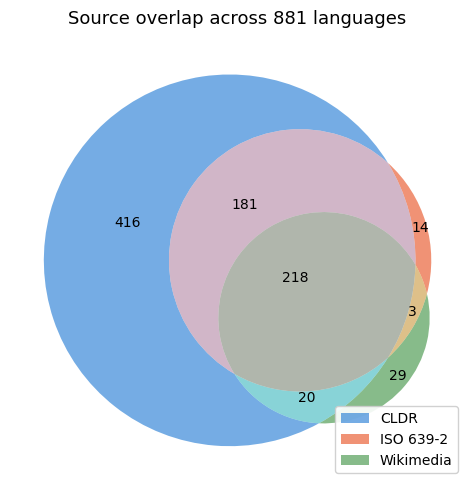

In [8]:
def combo_count(label):
    row = combo_counts[combo_counts["combination"] == label]
    return int(row["count"].iloc[0]) if len(row) else 0

# venn3 subsets order: (Abc, aBc, ABc, abC, AbC, aBC, ABC)
# A=CLDR, B=ISO 639-2, C=Wikimedia
subsets = (
    combo_count("CLDR"),
    combo_count("ISO 639-2"),
    combo_count("CLDR + ISO 639-2"),
    combo_count("Wikimedia"),
    combo_count("CLDR + Wikimedia"),
    combo_count("ISO 639-2 + Wikimedia"),
    combo_count("CLDR + ISO 639-2 + Wikimedia"),
)

COLORS = {"CLDR": "#1976d2", "ISO 639-2": "#e64a19", "Wikimedia": "#388e3c"}

fig, ax = plt.subplots(figsize=(7, 5))
v = venn3(
    subsets=subsets,
    set_labels=("", "", ""),
    set_colors=list(COLORS.values()),
    alpha=0.6,
    ax=ax,
)

legend_handles = [
    mpatches.Patch(facecolor=color, alpha=0.6, label=label)
    for label, color in COLORS.items()
]
ax.legend(handles=legend_handles, loc="lower right", framealpha=0.9, fontsize=10)

ax.set_title(f"Source overlap across {len(df)} languages", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

### Source Build-Up: Row Additions and Metadata Enrichment

The overlap view is useful for checking agreement between registries, but it does not show the project's conceptual build sequence. Here I reconstruct the target set in the order the language-selection logic expanded over time.

That conceptual progression was **ISO 639-1 -> Wikimedia -> ISO 639-2 -> CLDR**. I began from the narrow two-letter-code baseline used in the early translation materials, then widened to languages with active Wikimedia communities, then to the broader Library of Congress ISO 639-2 inventory, and finally to CLDR as the source that made scripts, directionality, local names, and modern-use distinctions legible at scale.

I separate **row additions** from **metadata enrichment**. A source can add a language that earlier steps lacked, but it can also add new evidence to rows already present. Wikimedia adds community infrastructure; ISO 639-2 adds bibliographic authority; CLDR adds localization metadata that the ISO lists do not supply.

For this reconstruction, the ISO 639-1 baseline is the original 185-code `iso_639_choices.csv` list used by the early translation materials. The current comprehensive CSV has a broader `in_iso639_1` flag because it also marks later two-letter Wikimedia/community identifiers. Those rows enter here at the Wikimedia step, not at the initial baseline.


In [46]:
def _as_bool(series):
    if str(series.dtype) == "bool":
        return series.fillna(False)
    return series.fillna(False).astype(str).str.lower().eq("true")

current_iso1_flag = _as_bool(df["in_iso639_1"])
historical_iso1_path = Path(DATA_DIR) / "metadata_files" / "iso_639_choices.csv"
historical_iso1_codes = set(
    pd.read_csv(historical_iso1_path, converters={"language": str})["language"]
    .dropna()
    .astype(str)
)
iso1 = df["language_code"].isin(historical_iso1_codes)
wiki = _as_bool(df["in_wikimedia"])
loc = _as_bool(df["in_iso639_2"])
cldr_any = df["sources"].fillna("").str.contains("cldr", regex=False)
cldr45 = df["cldr_version"].fillna("").eq("45")
cldr48 = df["cldr_version"].fillna("").eq("48.2.0")

two_letter_project_codes_outside_baseline = df.loc[
    current_iso1_flag & ~iso1,
    ["language_code", "language_name", "sources", "bcp47_tag", "bcp47_source"],
].sort_values("language_code")

# Reconstruct row growth in the conceptual order described above. These are
# cumulative selection masks, not the implementation order of the CSV builder.
stage_masks = [
    {
        "source_step": "ISO 639-1 baseline",
        "mask": iso1,
        "interpretation": "Original ISO 639-1 list used in the project's early translation materials",
    },
    {
        "source_step": "Wikimedia additions beyond ISO 639-1",
        "mask": wiki,
        "interpretation": "Active Wikipedia communities absent from the strict ISO 639-1 list",
    },
    {
        "source_step": "ISO 639-2 additions beyond earlier steps",
        "mask": loc,
        "interpretation": "Broader bibliographic language inventory beyond ISO 639-1 and Wikimedia",
    },
    {
        "source_step": "CLDR additions beyond ISO/Wikimedia/ISO 639-2",
        "mask": cldr_any,
        "interpretation": "Localization-oriented expansion that adds script, directionality, and usage metadata",
    },
]

def _examples(mask, n=8):
    ex = (
        df.loc[mask, ["language_code", "language_name"]]
        .sort_values("language_code")
        .head(n)
    )
    return ", ".join(f"{r.language_code} ({r.language_name})" for r in ex.itertuples())

addition_steps = []
seen = pd.Series(False, index=df.index)
for step in stage_masks:
    step_mask = step["mask"]
    added = step_mask & ~seen
    seen = seen | step_mask
    addition_steps.append({
        "source_step": step["source_step"],
        "rows_added": int(added.sum()),
        "cumulative_rows": int(seen.sum()),
        "interpretation": step["interpretation"],
        "examples": _examples(added),
    })

if int(seen.sum()) != len(df):
    missing = df.loc[~seen, ["language_code", "language_name", "sources"]]
    raise ValueError(
        "Conceptual source build-up does not cover every row in df. "
        f"Missing rows: {missing.to_dict(orient='records')[:10]}"
    )

addition_df = pd.DataFrame(addition_steps)
addition_df["start"] = addition_df["cumulative_rows"] - addition_df["rows_added"]
addition_df["end"] = addition_df["cumulative_rows"]
addition_df["label"] = addition_df.apply(
    lambda r: f"{int(r.rows_added)} total" if r.start == 0 else f"+{int(r.rows_added)} -> {int(r.end)}",
    axis=1,
)

earlier_than_cldr = iso1 | wiki | loc
cldr_breakdown = pd.DataFrame([
    {
        "cldr_component": "CLDR 48.2 rows added at the CLDR step",
        "rows": int((cldr48 & ~earlier_than_cldr).sum()),
        "meaning": "Core CLDR expansion from the live 48.2 dataset",
    },
    {
        "cldr_component": "CLDR v45 supplement rows added at the CLDR step",
        "rows": int((cldr45 & ~earlier_than_cldr).sum()),
        "meaning": "Previously dropped but retained rows folded into the final CLDR-stage expansion",
    },
])

metadata_enrichment = pd.DataFrame([
    {
        "metadata_signal": "Wikimedia confirms existing historical ISO 639-1 rows",
        "rows_enriched": int((wiki & iso1).sum()),
        "meaning": "Adds evidence of active community publishing without adding new rows",
    },
    {
        "metadata_signal": "ISO 639-2 confirms existing ISO 639-1/Wikimedia rows",
        "rows_enriched": int((loc & (iso1 | wiki)).sum()),
        "meaning": "Adds bibliographic authority without adding new rows",
    },
    {
        "metadata_signal": "CLDR confirms existing ISO/Wikimedia/ISO 639-2 rows",
        "rows_enriched": int((cldr_any & earlier_than_cldr).sum()),
        "meaning": "Adds script, directionality, and localization metadata without adding new rows",
    },
])

# Tables keep the exact counts and examples visible below the visual summary.
display(addition_df[["source_step", "rows_added", "cumulative_rows", "interpretation", "examples"]])
display(cldr_breakdown)
display(metadata_enrichment)
display(two_letter_project_codes_outside_baseline)

source_order = addition_df["source_step"].tolist()
source_colors = ["#546e7a", "#388e3c", "#e64a19", "#1976d2"]

growth_base = alt.Chart(addition_df).encode(
    y=alt.Y("source_step:N", sort=source_order, title=None),
    tooltip=[
        alt.Tooltip("source_step:N", title="Source step"),
        alt.Tooltip("rows_added:Q", title="Rows added"),
        alt.Tooltip("cumulative_rows:Q", title="Cumulative rows"),
        alt.Tooltip("interpretation:N", title="Interpretation"),
        alt.Tooltip("examples:N", title="Examples"),
    ],
)

growth_bars = growth_base.mark_bar(size=22).encode(
    x=alt.X("start:Q", title="cumulative language rows"),
    x2="end:Q",
    color=alt.Color(
        "source_step:N",
        legend=None,
        scale=alt.Scale(domain=source_order, range=source_colors),
    ),
)

growth_labels = growth_base.mark_text(align="left", dx=5, fontSize=10).encode(
    x="end:Q",
    text="label:N",
    color=alt.value("black"),
)

growth_chart = (growth_bars + growth_labels).properties(
    width=560,
    height=145,
    title=alt.Title(
        "How the target set grows under the project's conceptual source expansion",
        subtitle="Historical 185-code ISO 639-1 baseline, then Wikimedia, then ISO 639-2, then the final CLDR expansion",
    ),
)

cldr_bars = alt.Chart(cldr_breakdown).mark_bar(size=20, color="#8e44ad").encode(
    y=alt.Y("cldr_component:N", sort=None, title=None),
    x=alt.X("rows:Q", title="rows within the CLDR-stage expansion"),
    tooltip=["cldr_component:N", "rows:Q", "meaning:N"],
)
cldr_labels = cldr_bars.mark_text(align="left", dx=5, fontSize=10).encode(
    text="rows:Q",
    color=alt.value("black"),
)
cldr_chart = (cldr_bars + cldr_labels).properties(
    width=560,
    height=60,
    title=alt.Title(
        "What the CLDR step contributes",
        subtitle="The final expansion combines the main CLDR 48.2 inventory with the retained CLDR v45 supplement",
    ),
)

enrich_bars = alt.Chart(metadata_enrichment).mark_bar(size=20, color="#6f6f6f").encode(
    y=alt.Y("metadata_signal:N", sort=None, title=None),
    x=alt.X("rows_enriched:Q", title="existing rows enriched with additional source evidence"),
    tooltip=["metadata_signal:N", "rows_enriched:Q", "meaning:N"],
)
enrich_labels = enrich_bars.mark_text(align="left", dx=5, fontSize=10).encode(
    text="rows_enriched:Q",
    color=alt.value("black"),
)

enrichment_chart = (enrich_bars + enrich_labels).properties(
    width=560,
    height=95,
    title=alt.Title(
        "Later sources also enrich rows already in the target set",
        subtitle="These signals do not increase the row count, but they change how each row can be interpreted",
    ),
)

alt.vconcat(growth_chart, cldr_chart, enrichment_chart, spacing=18).resolve_scale(x="independent").configure_axis(
    labelLimit=0
)


,source_step,rows_added,cumulative_rows,interpretation,examples
0,ISO 639-1 baseline,185,185,Original ISO 639-1 list used in the project's ...,"aa (Afar), ab (Abkhazian), ae (Avestan), af (A..."
1,Wikimedia additions beyond ISO 639-1,87,272,Active Wikipedia communities absent from the s...,"als (Alemannic), ang (Old English), arc (Arama..."
2,ISO 639-2 additions beyond earlier steps,193,465,Broader bibliographic language inventory beyon...,"ace (Acehnese), ach (Acoli), ada (Adangme), ad..."
3,CLDR additions beyond ISO/Wikimedia/ISO 639-2,416,881,Localization-oriented expansion that adds scri...,"abq (Abaza), abr (Abron), aeb (Tunisian Arabic..."


,cldr_component,rows,meaning
0,CLDR 48.2 rows added at the CLDR step,393,Core CLDR expansion from the live 48.2 dataset
1,CLDR v45 supplement rows added at the CLDR step,23,Previously dropped but retained rows folded in...


,metadata_signal,rows_enriched,meaning
0,Wikimedia confirms existing historical ISO 639...,183,Adds evidence of active community publishing w...
1,ISO 639-2 confirms existing ISO 639-1/Wikimedi...,223,Adds bibliographic authority without adding ne...
2,CLDR confirms existing ISO/Wikimedia/ISO 639-2...,419,"Adds script, directionality, and localization ..."


,language_code,language_name,sources,bcp47_tag,bcp47_source
504,mo,Moldovan,wikimedia_only|iso639_1,ro,iso639_1
870,zg,Moroccan Amazigh,wikimedia_only|iso639_1,zg,iso639_1


alt.VConcatChart(...)

#### Follow-up: Metadata Enrichment After Row Selection

The build-up chart counts rows added to the target set. The follow-up chart keeps that same sequence and then continues through layers that mainly enrich existing rows: ISO 639-5 family classification, SIL ISO 639-3 English reference names, Glottolog reconciliation, and IANA/BCP 47 normalization through `langcodes`.

The bar length reports how many existing rows receive usable evidence from each layer. The annotation separates broad coverage from the smaller number of rows where a layer materially changes, repairs, or rewrites a value.


In [10]:
metadata_dir = Path(DATA_DIR) / "metadata_files"

# The first three layers continue the conceptual build sequence from the previous cell.
# They count rows that already existed at that point and gained a new source signal.
source_enrichment_rows = [
    {
        "layer": "Wikimedia after ISO 639-1",
        "rows_enriched": int((wiki & iso1).sum()),
        "material_change_count": int((wiki & iso1).sum()),
        "label": f"{int((wiki & iso1).sum())} confirmed",
        "meaning": "Existing ISO 639-1 rows gain evidence of active Wikimedia community publishing.",
        "examples": _examples(wiki & iso1),
    },
    {
        "layer": "ISO 639-2 after Wikimedia",
        "rows_enriched": int((loc & (iso1 | wiki)).sum()),
        "material_change_count": int((loc & (iso1 | wiki)).sum()),
        "label": f"{int((loc & (iso1 | wiki)).sum())} confirmed",
        "meaning": "Existing ISO/Wikimedia rows gain Library of Congress bibliographic authority.",
        "examples": _examples(loc & (iso1 | wiki)),
    },
    {
        "layer": "CLDR after ISO/Wikimedia/ISO 639-2",
        "rows_enriched": int((cldr_any & (iso1 | wiki | loc)).sum()),
        "material_change_count": int((cldr_any & (iso1 | wiki | loc)).sum()),
        "label": f"{int((cldr_any & (iso1 | wiki | loc)).sum())} enriched",
        "meaning": "Existing rows gain localization metadata: scripts, directionality, local names, modern-use flags.",
        "examples": _examples(cldr_any & (iso1 | wiki | loc)),
    },
]

# ISO 639-5 supplies the family-code layer used by the initial family_name field.
iso6395_mask = df["iso639_5_family"].fillna("").astype(str).str.len().gt(0)
family_label_mask = df["family_name"].fillna("").astype(str).str.len().gt(0)

# SIL is a name-repair layer, not a row source. The CSV stores only the final name,
# so reconstruct the fill count by asking which final names are absent from CLDR's
# English language-name table but present in the cached SIL ISO 639-3 table.
cldr_en_path = metadata_dir / "cldr-cache" / "cldr-localenames-full-48.2.0" / "main" / "en" / "languages.json"
sil_path = metadata_dir / "cldr-cache" / "iso-639-3.tab"
if cldr_en_path.exists() and sil_path.exists():
    cldr_en_names = json.loads(cldr_en_path.read_text())["main"]["en"]["localeDisplayNames"]["languages"]
    sil_names = pd.read_csv(sil_path, sep="\t", dtype=str, na_filter=False)
    sil_lookup = dict(zip(sil_names["Id"].str.strip(), sil_names["Ref_Name"].str.strip()))
    sil_lookup.update({"kro": "Kru languages", "tokipona": "Toki Pona"})
    sil_name_fill_mask = df.apply(
        lambda row: (
            row["language_code"] not in cldr_en_names
            and row["language_code"] in sil_lookup
            and row["language_name"] == sil_lookup[row["language_code"]]
        ),
        axis=1,
    )
else:
    sil_name_fill_mask = pd.Series(False, index=df.index)

# Glottolog match coverage is computed from the local cache in the same spirit as
# add_family_reconciliation(); the material-change count is the rows whose final
# reconciled family differs from the initial ISO 639-5-oriented family_name.
glot_path = metadata_dir / "glottolog-cache" / "languoid.csv"
if glot_path.exists():
    glot = pd.read_csv(glot_path, low_memory=False)
    glot_id_to_name = glot.set_index("id")["name"].to_dict()
    glot["glottolog_family"] = glot["family_id"].map(glot_id_to_name)
    glot_lang_codes = set(
        glot.loc[
            glot["level"].eq("language")
            & glot["iso639P3code"].notna()
            & glot["glottolog_family"].notna(),
            "iso639P3code",
        ].astype(str)
    )

    def _iso639_3_for_glottolog(row):
        for col in ("language_code", "iso639_2_t"):
            value = str(row.get(col, "") or "")
            if len(value) == 3:
                return value
        return ""

    glottolog_match_mask = df.apply(_iso639_3_for_glottolog, axis=1).isin(glot_lang_codes)
else:
    glottolog_match_mask = pd.Series(False, index=df.index)

glottolog_change_mask = (
    df["family_name_reconciled"].fillna("").astype(str)
    != df["family_name"].fillna("").astype(str)
)

# IANA/langcodes produces a BCP 47 interoperability tag for every row; the
# smaller material-change count records where that tag is not just the project
# language_code with case/underscore normalization.
bcp47_mask = df["bcp47_tag"].fillna("").astype(str).str.len().gt(0)
bcp47_change_mask = df["bcp47_tag"].fillna("").astype(str) != df["language_code"].astype(str)

post_selection_rows = [
    {
        "layer": "ISO 639-5 family layer",
        "rows_enriched": int(iso6395_mask.sum()),
        "material_change_count": int(family_label_mask.sum()),
        "label": f"{int(iso6395_mask.sum())} direct; {int(family_label_mask.sum())} labelled",
        "meaning": "Adds family and subfamily codes; fallback mapping gives every row a final family_name.",
        "examples": _examples(iso6395_mask),
    },
    {
        "layer": "SIL ISO 639-3 name repair",
        "rows_enriched": int(sil_name_fill_mask.sum()),
        "material_change_count": int(sil_name_fill_mask.sum()),
        "label": f"{int(sil_name_fill_mask.sum())} names filled",
        "meaning": "Repairs English names for codes absent from CLDR's English language-name table.",
        "examples": _examples(sil_name_fill_mask),
    },
    {
        "layer": "Glottolog reconciliation",
        "rows_enriched": int(glottolog_match_mask.sum()),
        "material_change_count": int(glottolog_change_mask.sum()),
        "label": f"{int(glottolog_match_mask.sum())} matched; {int(glottolog_change_mask.sum())} reclassified",
        "meaning": "Cross-checks family assignments against Glottolog and applies documented reconciliation decisions.",
        "examples": _examples(glottolog_change_mask),
    },
    {
        "layer": "IANA via langcodes",
        "rows_enriched": int(bcp47_mask.sum()),
        "material_change_count": int(bcp47_change_mask.sum()),
        "label": f"{int(bcp47_mask.sum())} tagged; {int(bcp47_change_mask.sum())} rewritten",
        "meaning": "Adds BCP 47 interoperability tags and surfaces IANA Preferred-Value or grandfathered-code rewrites.",
        "examples": _examples(bcp47_change_mask),
    },
]

enrichment_sequence = pd.DataFrame(source_enrichment_rows + post_selection_rows)
enrichment_sequence["step"] = range(1, len(enrichment_sequence) + 1)

# Tables preserve the exact calculation and examples alongside the visual summary.
display(enrichment_sequence[[
    "step", "layer", "rows_enriched", "material_change_count", "meaning", "examples"
]])

layer_order = enrichment_sequence["layer"].tolist()
layer_colors = [
    "#388e3c", "#e64a19", "#1976d2", "#7b6f52", "#8e44ad", "#455a64", "#6a4c93"
]

coverage_bars = alt.Chart(enrichment_sequence).mark_bar(size=20).encode(
    y=alt.Y("layer:N", sort=layer_order, title=None),
    x=alt.X("rows_enriched:Q", title="existing rows enriched by this layer"),
    color=alt.Color(
        "layer:N",
        legend=None,
        scale=alt.Scale(domain=layer_order, range=layer_colors),
    ),
    tooltip=[
        alt.Tooltip("step:O", title="Step"),
        alt.Tooltip("layer:N", title="Layer"),
        alt.Tooltip("rows_enriched:Q", title="Rows enriched"),
        alt.Tooltip("material_change_count:Q", title="Material changes / repairs"),
        alt.Tooltip("meaning:N", title="Meaning"),
        alt.Tooltip("examples:N", title="Examples"),
    ],
)
coverage_labels = coverage_bars.mark_text(align="left", dx=5, fontSize=10).encode(
    text="label:N",
    color=alt.value("black"),
)

(coverage_bars + coverage_labels).properties(
    width=640,
    height=245,
    title=alt.Title(
        "How later sources enrich the selected language rows",
        subtitle="After row selection: ISO 639-5, SIL ISO 639-3, Glottolog, and IANA/langcodes add interpretive metadata rather than new rows",
    ),
).configure_view(strokeWidth=0)


,step,layer,rows_enriched,material_change_count,meaning,examples
0,1,Wikimedia after ISO 639-1,183,183,Existing ISO 639-1 rows gain evidence of activ...,"aa (Afar), ab (Abkhazian), af (Afrikaans), ak ..."
1,2,ISO 639-2 after Wikimedia,223,223,Existing ISO/Wikimedia rows gain Library of Co...,"aa (Afar), ab (Abkhazian), ae (Avestan), af (A..."
2,3,CLDR after ISO/Wikimedia/ISO 639-2,419,419,Existing rows gain localization metadata: scri...,"aa (Afar), ab (Abkhazian), ace (Acehnese), ach..."
3,4,ISO 639-5 family layer,867,881,Adds family and subfamily codes; fallback mapp...,"aa (Afar), ab (Abkhazian), abq (Abaza), abr (A..."
4,5,SIL ISO 639-3 name repair,223,223,Repairs English names for codes absent from CL...,"abq (Abaza), abr (Abron), aii (Assyrian Neo-Ar..."
5,6,Glottolog reconciliation,772,295,Cross-checks family assignments against Glotto...,"ab (Abkhazian), abq (Abaza), abr (Abron), ach ..."
6,7,IANA via langcodes,879,17,Adds BCP 47 interoperability tags and surfaces...,"bat-smg (Samogitian), be-x-old (Belarusian (Ta..."


alt.LayerChart(...)

### CLDR version provenance and the v45 supplement

The `cldr_version` column records which CLDR release each row came from. I use it to distinguish three cases:

| `cldr_version` | Meaning |
|---|---|
| `'48.2.0'` | Core CLDR 48.2 JSON fetch, authoritative here for scripts, directionality, and modern-use flags |
| `'45'` | CLDR v45 supplement, languages present in CLDR 45 but absent from 48.2 |
| `''` | Wikimedia-only or LOC-only rows with no CLDR data |

I keep the CLDR v45 supplement because CLDR removal is an administrative signal, not a linguistic one. If a community stops submitting the Core data required for OS-level localization, that does not mean the language should disappear from this project's translation analysis. The supplement lets me preserve those rows while still recording that their current CLDR status differs from the 48.2 baseline.

The earlier source-overlap chart treats supplement rows as CLDR-related because their `sources` field contains `cldr`. The conceptual build-up section separates the 48.2 additions from the retained v45 supplement so that the version history remains visible.


In [11]:
if "cldr_version" not in df.columns:
    print("⚠  cldr_version not in CSV — re-run generate_language_codes.py to see this section.")
    dropped_chart = None
else:
    ver_label = {
        "48.2.0": "CLDR 48.2 (primary)",
        "45":     "CLDR v45 supplement",
        "":       "Wikimedia / LOC only",
    }
    ver_counts = (
        df["cldr_version"].fillna("").map(ver_label).fillna("other")
        .value_counts()
        .rename_axis("source")
        .reset_index(name="count")
    )
    print("Version provenance breakdown:")
    print(ver_counts.to_string(index=False))
    print()

    supp = (
        df[df["cldr_version"] == "45"]
        [["language_code", "language_name", "directionality", "family_name"]]
        .sort_values(["family_name", "language_code"])
        .reset_index(drop=True)
    )
    print(f"CLDR v45 supplement — {len(supp)} languages retained from CLDR 45:")
    print(supp.to_string(index=False))

    # ── Chart: supplement languages by family ────────────────────────────────
    supp_fam = supp["family_name"].value_counts().reset_index()
    supp_fam.columns = ["family", "count"]

    bars = alt.Chart(supp_fam).mark_bar(color="#c0392b").encode(
        y=alt.Y("family:N", sort="-x", title=None),
        x=alt.X("count:Q", title="languages in supplement"),
        tooltip=["family:N", "count:Q"],
    )
    text = bars.mark_text(align="left", dx=4, fontSize=10).encode(
        text="count:Q", color=alt.value("black"))

    dropped_chart = (bars + text).properties(
        width=420, height=220,
        title=alt.Title(
            "CLDR v45 supplement: 23 languages by family",
            subtitle="Dropped from CLDR 48.2 for contributor-policy reasons, not linguistic ones — retained here for scholarly translation coverage",
        )
    )
dropped_chart

Version provenance breakdown:
              source  count
 CLDR 48.2 (primary)    812
Wikimedia / LOC only     46
 CLDR v45 supplement     23

CLDR v45 supplement — 23 languages retained from CLDR 45:
language_code              language_name directionality                     family_name
          shu             Chadian Arabic            rtl          Afro-Asiatic languages
          lou           Louisiana Creole            ltr             Creoles and pidgins
          ike Eastern Canadian Inuktitut            ltr          Eskimo-Aleut languages
          gom               Goan Konkani            ltr         Indo-European languages
          hax             Southern Haida            ltr                Language isolate
          hdn             Northern Haida            ltr                Language isolate
          lsm                     Saamia            ltr     Niger-Kordofanian languages
          mye                      Myene            ltr     Niger-Kordofanian languages
       

alt.LayerChart(...)

### English Name Coverage: SIL ISO 639-3 Enrichment

CLDR's English locale-name file does not name every code that CLDR otherwise includes. Without enrichment, some rows would fall back to the code itself as `language_name`.

I use SIL's ISO 639-3 reference table only to fill those English display names. This is name enrichment, not row creation. The missing names include living languages such as Abaza (`abq`), Bhilali (`bhi`), Kanauji (`bjj`), and Balanta-Ganja (`bjt`), as well as ancient or undeciphered scripts such as Mycenaean Greek (`gmy`), Linear A (`lab`), Carian (`xcr`), and Meroitic (`xmr`).

Any remaining exceptional cases are filled from `_SIL_NAME_OVERRIDES`:

| Code | Name | Reason not in SIL |
|------|------|-------------------|
| `kro` | Kru languages | ISO 639-5 group code; SIL ISO 639-3 covers individual languages only |
| `tokipona` | Toki Pona | Wikimedia-only composite tag used before the later `tok` subtag |

After this enrichment, every row has a human-readable `language_name`. The next cell calculates how many names were filled and where they came from.


In [12]:
# Ground truth: which codes CLDR's en/languages.json directly names
en_langs_path = os.path.join(
    DATA_DIR, "metadata_files", "cldr-cache",
    "cldr-localenames-full-48.2.0", "main", "en", "languages.json"
)
with open(en_langs_path, encoding="utf-8") as _f:
    cldr_en_names = set(
        json.load(_f)["main"]["en"]["localeDisplayNames"]["languages"].keys()
    )

# SIL reference names
sil_path = os.path.join(DATA_DIR, "metadata_files", "cldr-cache", "iso-639-3.tab")
sil = pd.read_csv(sil_path, sep="\t", dtype=str, na_filter=False)
sil_names = dict(zip(sil["Id"].str.strip(), sil["Ref_Name"].str.strip()))
sil_overrides = {"kro": "Kru languages", "tokipona": "Toki Pona"}

# Previously unnamed codes fall into two groups:
# 1. CLDR codes (sources contains 'cldr', not 'cldr_v45') absent from CLDR's en/languages.json
# 2. The two hardcoded overrides (kro: ISO 639-5 group code; tokipona: Wikimedia-only tag)
#    — tokipona is wikimedia_only so would otherwise slip through the CLDR filter
unnamed_mask = (
    (
        df["sources"].str.contains("cldr", na=False)
        & ~df["sources"].str.fullmatch("cldr_v45", na=False)
        & ~df["language_code"].isin(cldr_en_names)
    )
    | df["language_code"].isin(sil_overrides)
)

def _fill_source(code):
    if code in sil_overrides:
        return "Hardcoded override"
    if code in sil_names:
        return "SIL ISO 639-3"
    return "Other"

sil_filled = df[unnamed_mask].copy()
sil_filled["fill_source"] = sil_filled["language_code"].map(_fill_source)

print(f"Codes with no CLDR English name (previously code-as-name): {len(sil_filled)}")
print(f"  Filled by SIL ISO 639-3:  {(sil_filled['fill_source'] == 'SIL ISO 639-3').sum()}")
print(f"  Filled by override:       {(sil_filled['fill_source'] == 'Hardcoded override').sum()}")
print(f"  Still unnamed:            {(sil_filled['fill_source'] == 'Other').sum()}")
print()

sil_filled[["language_code", "language_name", "family_name", "modern_language", "fill_source"]].sort_values(
    ["family_name", "language_code"]
).reset_index(drop=True)

Codes with no CLDR English name (previously code-as-name): 216
  Filled by SIL ISO 639-3:  214
  Filled by override:       2
  Still unnamed:            0



,language_code,language_name,family_name,modern_language,fill_source
0,aii,Assyrian Neo-Aramaic,Afro-Asiatic languages,True,SIL ISO 639-3
1,apc,Levantine Arabic,Afro-Asiatic languages,True,SIL ISO 639-3
2,apd,Sudanese Arabic,Afro-Asiatic languages,True,SIL ISO 639-3
3,grr,Taznatit,Afro-Asiatic languages,True,SIL ISO 639-3
4,mey,Hassaniyya,Afro-Asiatic languages,True,SIL ISO 639-3
...,...,...,...,...,...
211,tts,Northeastern Thai,Tai-Kadai languages,True,SIL ISO 639-3
212,lab,Linear A,Undeciphered script,False,SIL ISO 639-3
213,kca,Khanty,Uralic languages,True,SIL ISO 639-3
214,mns,Mansi,Uralic languages,True,SIL ISO 639-3


#### Date provenance: how I handle shifting upstream registries

Live registries change. Wikimedia can add or remove projects, and CLDR can drop locales when maintenance requirements are not met. A one-time snapshot would hide that movement, so I added date-provenance columns to the comprehensive CSV.

- `coding_dh_date_added` records when a code was first attested in any regeneration. For older rows, the value was bootstrapped from the repository history of the comprehensive CSV.
- `coding_dh_date_last_seen` records when a code was last confirmed in the current upstream sources. If a code later disappears, I retain the row and leave `coding_dh_date_last_seen` unchanged, so the date gap becomes evidence of registry drift.

This extends the same logic as the CLDR v45 supplement: once a language community has entered the project through a trusted source, I do not remove it silently just because an upstream registry changes. The next cell reports the current first-attested date distribution.


In [13]:
date_added_counts = (
    df["coding_dh_date_added"]
    .fillna("unknown")
    .value_counts()
    .rename_axis("coding_dh_date_added")
    .reset_index(name="n_codes")
    .sort_values("coding_dh_date_added")
)

date_last_seen_counts = (
    df["coding_dh_date_last_seen"]
    .fillna("unknown")
    .value_counts()
    .rename_axis("coding_dh_date_last_seen")
    .reset_index(name="n_codes")
    .sort_values("coding_dh_date_last_seen")
)

print(f"Current distribution across the {len(df)}-row CSV:")
print()
print("First attested dates:")
print(date_added_counts.to_string(index=False))
print()
print("Last-seen dates:")
print(date_last_seen_counts.to_string(index=False))


Current distribution across the 881-row CSV:

First attested dates:
coding_dh_date_added  n_codes
          2026-04-22      856
          2026-05-15       24
          2026-06-15        1

Last-seen dates:
coding_dh_date_last_seen  n_codes
              2026-06-15      881


### Translation Service Support Coverage

Source attestation is not the same as translation support. I therefore also track whether major commercial translation services advertise support for each language code. The comprehensive CSV currently carries two Google support columns derived from `service_language_code_support.csv`:

- `google_nmt_supported` - official support in Google's standard Neural Machine Translation API
- `google_translation_llm_supported` - official support in Google's newer Translation LLM endpoint

I keep both because they measure different parts of the long tail. The Translation LLM is the higher-quality tier but covers fewer languages; NMT is broader but still far from universal. The gap from LLM support to NMT support to unsupported languages gives me one operational measure of uneven translation infrastructure.

The support flags are populated by `add_service_language_codes()`, which compares `language_code`, `bcp47_tag`, and known IANA aliases from `langcodes.LANGUAGE_REPLACEMENTS` against Google's published support snapshot. This matters for deprecated or alternate codes such as Hebrew `iw`/`he` and Javanese `jw`/`jv`.


#### Upstream support manifest: what Google's API itself says

Before counting how many project rows Google supports, I first inspect Google's own support manifest. The cell below loads `service_language_code_support.csv`, refreshed by `python -m scripts.experiment.curation.refresh_service_support`, and reports the service totals, snapshot date, and source.

I also compare Google's supported codes with the pipeline rows. Some Google codes are locale variants such as `ar-SA`, `es-MX`, or `zh-TW`; this project generally does not split languages into every locale variant, so those are useful mismatches rather than errors.


In [14]:
# Upstream support manifest — straight from the snapshot CSV
support_path = Path('..') / 'datasets' / 'metadata_files' / 'service_language_code_support.csv'
support = pd.read_csv(support_path, dtype=str, na_filter=False)

print(f'Manifest path: {support_path}')
print()
print(f"{'service':<28} {'rows':>5}  {'snapshot_date':<14}  snapshot_source")
print('-' * 100)
for service, sdf in support.groupby('service'):
    snap = sdf['snapshot_date'].iloc[0] if 'snapshot_date' in sdf.columns else '\u2014'
    src  = sdf['snapshot_source'].iloc[0] if 'snapshot_source' in sdf.columns else '\u2014'
    print(f'{service:<28} {len(sdf):>5}  {snap:<14}  {src}')

print()
print(f"Overlap with the {len(df)}-row pipeline (a 'pipeline match' = Google's code was selected by a row in df):")
for service, sdf in support.groupby('service'):
    matched_col = f'{service}_code'
    if matched_col not in df.columns:
        print(f'  {service}: column {matched_col} not in df; skipping')
        continue
    pipeline_codes_matched = set(df[matched_col].dropna()) - {''}
    google_codes = set(sdf['service_code'])
    in_pipeline = google_codes & pipeline_codes_matched
    out_of_pipeline = google_codes - pipeline_codes_matched
    print(f'  {service}: {len(google_codes)} supported  \u2192  '
          f'{len(in_pipeline)} match a pipeline row, '
          f'{len(out_of_pipeline)} do not')
    if out_of_pipeline:
        examples = sorted(out_of_pipeline)[:10]
        print(f"      out-of-pipeline examples: {', '.join(examples)}")


Manifest path: ../datasets/metadata_files/service_language_code_support.csv

service                       rows  snapshot_date   snapshot_source
----------------------------------------------------------------------------------------------------
google_nmt                     196  2026-06-15      translate_v3.get_supported_languages
google_translation_llm         127  2026-06         manual_paste_from_cloud.google.com_docs

Overlap with the 881-row pipeline (a 'pipeline match' = Google's code was selected by a row in df):
  google_nmt: 196 supported  →  180 match a pipeline row, 16 do not
      out-of-pipeline examples: alz, bts, btx, cnh, dov, fil, fr-CA, hrx, iw, jw
  google_translation_llm: 127 supported  →  85 match a pipeline row, 42 do not
      out-of-pipeline examples: ar-SA, bn-IN, bs-Cyrl, en-AU, en-CA, en-GB, en-NZ, en-PH, en-US, en-ZA


In [15]:
# Service-coverage summary
service_cov = pd.DataFrame({
    'tier':  ['LLM-grade (Translation LLM)', 'NMT-grade (standard NMT)',
              'NMT only (no LLM support)', 'Neither service'],
    'count': [
        int(df['google_translation_llm_supported'].fillna(False).sum()),
        int(df['google_nmt_supported'].fillna(False).sum()),
        int((df['google_nmt_supported'].fillna(False) & ~df['google_translation_llm_supported'].fillna(False)).sum()),
        int((~df['google_nmt_supported'].fillna(False) & ~df['google_translation_llm_supported'].fillna(False)).sum()),
    ],
})
service_cov['pct'] = (service_cov['count'] / len(df) * 100).round(1)
print(f'Total pipeline languages: {len(df)}')
print()
print(service_cov.to_string(index=False))

Total pipeline languages: 881

                       tier  count  pct
LLM-grade (Translation LLM)     87  9.9
   NMT-grade (standard NMT)    184 20.9
  NMT only (no LLM support)     98 11.1
            Neither service    696 79.0


In [16]:
# Three buckets: in LLM, in NMT only, in neither
buckets = pd.DataFrame({
    'tier':  ['Translation LLM',
              'NMT only',
              'Unsupported by both'],
    'count': [
        int(df['google_translation_llm_supported'].fillna(False).sum()),
        int((df['google_nmt_supported'].fillna(False) & ~df['google_translation_llm_supported'].fillna(False)).sum()),
        int((~df['google_nmt_supported'].fillna(False) & ~df['google_translation_llm_supported'].fillna(False)).sum()),
    ],
})
buckets['pct'] = (buckets['count'] / len(df) * 100).round(1)
buckets['label'] = buckets.apply(lambda r: f"{r['count']} ({r['pct']:.1f}%)", axis=1)

tier_colors = {
    'Translation LLM':     '#1976d2',
    'NMT only':            '#c0680c',
    'Unsupported by both': '#9e9e9e',
}

bar = alt.Chart(buckets).mark_bar().encode(
    y=alt.Y('tier:N', sort=['Translation LLM', 'NMT only', 'Unsupported by both'], title=None),
    x=alt.X('count:Q', title='languages'),
    color=alt.Color('tier:N',
                    scale=alt.Scale(domain=list(tier_colors), range=list(tier_colors.values())),
                    legend=None),
    tooltip=['tier:N', 'count:Q', 'pct:Q'],
).properties(
    width=420, height=140,
    title=alt.Title(
        f'Google Translation service coverage across {len(df)} pipeline languages',
        subtitle='The unsupported-by-both bucket is the long tail this paper studies',
    ),
)
text = bar.mark_text(align='left', dx=5, fontSize=11).encode(text='label:N', color=alt.value('black'))
(bar + text)

alt.LayerChart(...)

In [17]:
# Sanity: how often does our internal `language_code` already match Google's exact code?
for col in ['google_nmt_code', 'google_translation_llm_code']:
    matched = df[df[col].fillna('').astype(str).str.len() > 0]
    if matched.empty:
        continue
    same = (matched[col].astype(str) == matched['language_code'].astype(str)).sum()
    print(f'{col}: {len(matched)} matched | {same} match the project code directly | '
          f'{len(matched)-same} matched via BCP47 / ISO alias')

google_nmt_code: 184 matched | 179 match the project code directly | 5 matched via BCP47 / ISO alias
google_translation_llm_code: 87 matched | 84 match the project code directly | 3 matched via BCP47 / ISO alias


## 1.3 Constructing the Target Set

This section asks why the target set is this size. Different filters would produce defensible but different projects: only active Wikimedia languages, only modern CLDR languages, only languages with ISO 639-2 authority, or the full comprehensive set.

I use the full set. That means I keep languages without Wikipedia presence, languages outside ISO 639-2, and languages CLDR marks as non-modern. The sections below show what each narrower filter would exclude and why I decided not to use it as the final boundary.


In [18]:
# Show the original translated DH terms dataset to get a sense of the number of translations and languages covered. This dataset was generated in December 2022.
original_translated_dh_terms = pd.read_csv(os.path.join("..", "historic_materials", "translated_dh_terms.csv"))
original_translated_dh_terms = original_translated_dh_terms[original_translated_dh_terms.term_source == "Digital Humanities"]
print(f"Original translated DH terms: {len(original_translated_dh_terms)} rows")
print(f"Number of actually translated terms: {original_translated_dh_terms[original_translated_dh_terms.translated_term.notnull()].shape[0]} unique translations")
print(f"{original_translated_dh_terms[original_translated_dh_terms.translated_term.isnull()].language_name.nunique()} Languages not translated: {original_translated_dh_terms[original_translated_dh_terms.translated_term.isnull()].language_name.unique().tolist()}")

Original translated DH terms: 185 rows
Number of actually translated terms: 123 unique translations
62 Languages not translated: ['Abkhaz', 'Afar', 'Aragonese', 'Avaric', 'Avestan', 'Bashkir', 'Bislama', 'Breton', 'Chamorro', 'Chechen', 'Chuvash', 'Cornish', 'Cree', 'Dzongkha', 'Faroese', 'Fijian', 'Fula', 'Herero', 'Hiri Motu', 'Interlingua', 'Interlingue', 'Inupiaq', 'Ido', 'Inuktitut', 'Kalaallisut', 'Kanuri', 'Kashmiri', 'Kikuyu, Gikuyu', 'Komi', 'Kongo', 'Kwanyama, Kuanyama', 'Limburgish', 'Luba-Katanga', 'Manx', 'Marshallese', 'Nauru', 'Navajo, Navaho', 'North Ndebele', 'Ndonga', 'Norwegian Nynorsk', 'Nuosu', 'South Ndebele', 'Occitan', 'Ojibwe, Ojibwa', 'Old Church Slavonic', 'Ossetian, Ossetic', 'Pāli', 'Romansh', 'Kirundi', 'Sardinian', 'Northern Sami', 'Sango', 'Swati', 'Tibetan', 'Tswana', 'Tonga', 'Tahitian', 'Venda', 'Volapük', 'Walloon', 'Wolof', 'Zhuang, Chuang']


In [19]:
filters = {
    f"All {n_languages} (pipeline default)":  pd.Series([True] * len(df)),
    "Wikimedia only":                          df["in_wikimedia"].fillna(False),
    "Modern + ISO 639-2 or Wikimedia":         df["modern_language"] & (df["in_iso639_2"] | df["in_wikimedia"]),
    "All modern":                              df["modern_language"].fillna(False),
}

rows = []
for label, mask in filters.items():
    subset = df[mask]
    rows.append({
        "filter": label,
        "total":  len(subset),
        "ltr":    (subset["directionality"] == "ltr").sum(),
        "rtl":    (subset["directionality"] == "rtl").sum(),
        "iso639_1": subset["in_iso639_1"].sum(),
        "iso639_2": subset["in_iso639_2"].sum(),
        "wikimedia": subset["in_wikimedia"].sum(),
    })
filter_df = pd.DataFrame(rows)
filter_df

,filter,total,ltr,rtl,iso639_1,iso639_2,wikimedia
0,All 881 (pipeline default),881,802,79,187,416,270
1,Wikimedia only,270,253,17,185,221,270
2,Modern + ISO 639-2 or Wikimedia,453,428,25,186,404,268
3,All modern,856,787,69,186,404,268


In [20]:
filter_order = filter_df["filter"].tolist()

bar = alt.Chart(filter_df).mark_bar().encode(
    y=alt.Y("filter:N", sort=filter_order, title=None),
    x=alt.X("total:Q", title="languages in target set"),
    color=alt.Color("filter:N", legend=None, scale=alt.Scale(scheme="tableau10")),
    tooltip=["filter:N", "total:Q", "ltr:Q", "rtl:Q", "wikimedia:Q"],
).properties(width=420, height=160, title="Target set size by filter strategy")

text = bar.mark_text(align="left", dx=4, fontSize=10).encode(
    text="total:Q", color=alt.value("black"))

bar + text

alt.LayerChart(...)

In [21]:
# Stacked LTR/RTL breakdown
dir_rows = []
for _, r in filter_df.iterrows():
    dir_rows.append({"filter": r["filter"], "direction": "LTR", "count": r["ltr"]})
    dir_rows.append({"filter": r["filter"], "direction": "RTL", "count": r["rtl"]})
dir_df = pd.DataFrame(dir_rows)

dir_bar = alt.Chart(dir_df).mark_bar().encode(
    y=alt.Y("filter:N", sort=filter_order, title=None),
    x=alt.X("count:Q", title="languages"),
    color=alt.Color("direction:N",
        scale=alt.Scale(domain=["LTR", "RTL"], range=["#1976d2", "#e64a19"]),
        title="direction"),
    tooltip=["filter:N", "direction:N", "count:Q"],
).properties(width=420, height=160, title="LTR / RTL split by filter strategy")

dir_bar

alt.Chart(...)

### Expansion Steps

This expansion view is calculated from the current CSV. It starts with Wikimedia languages, then adds modern languages with ISO 639-2 or Wikimedia attestation, then adds remaining CLDR-modern languages, and finally retains the CLDR non-modern rows discussed below. The cell reports the current size of each step and previews the rows added at each expansion.


In [22]:
wiki_mask = df["in_wikimedia"].fillna(False)
iso2_or_wiki_mask = df["modern_language"] & (df["in_iso639_2"] | df["in_wikimedia"])
modern_mask = df["modern_language"].fillna(False)
non_modern_mask = ~modern_mask

# Languages in ISO2-or-Wikimedia but NOT in Wikimedia-only
iso2_additions = df[iso2_or_wiki_mask & ~wiki_mask][
    ["language_code", "language_name", "directionality", "family_name", "sources"]
].sort_values("language_name").reset_index(drop=True)

# Languages in All-Modern but NOT in ISO2-or-Wikimedia
modern_additions = df[modern_mask & ~iso2_or_wiki_mask][
    ["language_code", "language_name", "directionality", "family_name", "sources"]
].sort_values("language_name").reset_index(drop=True)

print("Target-set expansion sequence:")
print(f"  Wikimedia only:                         {int(wiki_mask.sum()):>4}")
print(f"  Modern + ISO 639-2 or Wikimedia:        {int(iso2_or_wiki_mask.sum()):>4}  (+{len(iso2_additions)})")
print(f"  All CLDR-modern languages:              {int(modern_mask.sum()):>4}  (+{len(modern_additions)})")
print(f"  Full pipeline target set:               {len(df):>4}  (+{int(non_modern_mask.sum())} non-modern rows)")
print()

print("=== ISO 639-2/Wikimedia expansion additions (sample) ===")
print(iso2_additions.head(20).to_string(index=False))


Target-set expansion sequence:
  Wikimedia only:                          270
  Modern + ISO 639-2 or Wikimedia:         453  (+185)
  All CLDR-modern languages:               856  (+403)
  Full pipeline target set:                881  (+25 non-modern rows)

=== ISO 639-2/Wikimedia expansion additions (sample) ===
language_code language_name directionality                     family_name       sources
          ace      Acehnese            ltr          Austronesian languages cldr|iso639_2
          ach         Acoli            ltr          Nilo-Saharan languages cldr|iso639_2
          ada       Adangme            ltr     Niger-Kordofanian languages cldr|iso639_2
          ady        Adyghe            ltr             Caucasian languages cldr|iso639_2
          afh      Afrihili            ltr            Artificial languages      loc_only
          ain          Ainu            ltr                Language isolate cldr|iso639_2
          ale         Aleut            ltr          Eskimo-Al

In [23]:
print("=== Additional languages from CLDR-only (all modern, no ISO 639-2 or Wikimedia) ===")
print(modern_additions.to_string(index=False))

=== Additional languages from CLDR-only (all modern, no ISO 639-2 or Wikimedia) ===
language_code                  language_name directionality                       family_name  sources
          abq                          Abaza            ltr               Caucasian languages     cldr
          abr                          Abron            ltr       Niger-Kordofanian languages     cldr
          agq                          Aghem            ltr       Niger-Kordofanian languages     cldr
          bss                         Akoose            ltr       Niger-Kordofanian languages     cldr
          akz                        Alabama            ltr   North American Indian languages     cldr
          arq                Algerian Arabic            rtl            Afro-Asiatic languages     cldr
          ase         American Sign Language            ltr                    Sign languages cldr_v45
          amo                            Amo            ltr       Niger-Kordofanian language

### Non-Modern Languages

CLDR's `cldr_type` flag distinguishes languages it labels modern from those it labels `O`, a broad category that includes ancient, extinct, and constructed languages. The `modern_language` column is derived from that flag. I treat it as CLDR metadata, not as a judgment about whether a language matters to this project.

I do not filter on it. If an LLM attempts, refuses, or hallucinates a translation into Latin, Linear A, Esperanto, or another non-modern CLDR category, that behavior is part of the evidence. The table below records which rows CLDR flags this way; it is not a list of rows I exclude.


In [24]:
non_modern = df[~df["modern_language"].fillna(True)].copy()
non_modern["has_wikipedia"] = non_modern["in_wikimedia"].fillna(False)
non_modern["has_iso639_1"]  = non_modern["in_iso639_1"].fillna(False)
non_modern["has_iso639_2"]  = non_modern["in_iso639_2"].fillna(False)

display_cols = ["language_code", "language_name", "directionality",
                "has_wikipedia", "has_iso639_1", "has_iso639_2", "family_name"]

print(f"Total non-modern: {len(non_modern)}")
print(f"  With active Wikipedia: {non_modern['has_wikipedia'].sum()}")
print(f"  With ISO 639-1 code:   {non_modern['has_iso639_1'].sum()}")
print()
non_modern[display_cols].sort_values(
    ["has_wikipedia", "has_iso639_1"], ascending=False
).reset_index(drop=True)

Total non-modern: 25
  With active Wikipedia: 2
  With ISO 639-1 code:   1



,language_code,language_name,directionality,has_wikipedia,has_iso639_1,has_iso639_2,family_name
0,arc,Aramaic,rtl,True,False,True,Afro-Asiatic languages
1,got,Gothic,ltr,True,False,True,Indo-European languages
2,ae,Avestan,rtl,False,True,True,Indo-European languages
3,akk,Akkadian,ltr,False,False,True,Afro-Asiatic languages
4,ecy,Eteocypriot,rtl,False,False,False,Indo-European languages
5,egy,Ancient Egyptian,ltr,False,False,True,Afro-Asiatic languages
6,gmy,Mycenaean Greek,rtl,False,False,False,Indo-European languages
7,hit,Hittite,ltr,False,False,True,Indo-European languages
8,lab,Linear A,ltr,False,False,False,Undeciphered script
9,mnc,Manchu,ltr,False,False,True,Altaic languages


### A structural edge case: `uz_AF`

`uz_AF` is Wikimedia's code for Afghan Uzbek, a variety written in Perso-Arabic script in northern Afghanistan. Wikimedia marks it as right-to-left, but it has no CLDR script metadata. Without a fallback, the script pass would default to left-to-right.

I correct this in `build_comprehensive`: when a Wikimedia-only code lacks CLDR script data but Wikimedia marks it `rtl`, I restore `rtl`. This is a small but important example of why I do not always let the more formal registry win. For this row, Wikimedia is closer to the writing practice I need to represent.


## 1.4 Language Families

Language family is the main grouping variable I use later to compare translation patterns across the dataset. That makes it useful, but also risky: a family label can make the data look more settled than it really is. I therefore treat family assignment as a layered metadata problem rather than as a single authoritative lookup.

The first layer is the generated `family_name` column. It is anchored in ISO 639-5 family and collection codes, read through CLDR's `languageGroups.json`, and then filled out with a manual map and the older `language_family_assignments.json` fallback for codes that ISO 639-5/CLDR does not cover cleanly. That gives every language row a starting family label, but it also imports ISO 639-5's limitations: the standard mixes genealogical families with geographic groupings, collective labels, and older macrofamilies.

The rest of this section asks how much confidence I should have in that starting layer. First I show the raw family distribution and the evidence behind `family_name`. Then I compare those labels with Glottolog 5.3, apply the base reconciliation stored in `family_reconciliation.csv`, and finally show the reviewed family layer used for downstream analysis: `family_name_reconciled_reviewed` and `family_name_analysis` in `language_codes_comprehensive_family_reviewed.csv`.


### Raw Family Distribution by Target-Set Filter

This first chart deliberately uses the raw `family_name` column. At this point I am not yet asking whether the family labels are the best linguistic categories. I am asking what the generated language list looks like before Glottolog reconciliation, and how that composition changes under the candidate target-set filters from §1.3.


In [25]:
family_rows = []
for label, mask in filters.items():
    subset = df[mask]
    counts = subset["family_name"].fillna("Unknown / unassigned").value_counts().reset_index()
    counts.columns = ["family", "count"]
    counts["filter"] = label
    family_rows.append(counts)
family_long = pd.concat(family_rows, ignore_index=True)

# Focus on top 15 families across all filters
top_families = (
    family_long.groupby("family")["count"].sum()
    .nlargest(15).index.tolist()
)
plot_df = family_long[family_long["family"].isin(top_families)]

alt.Chart(plot_df).mark_bar().encode(
    x=alt.X("count:Q", title="languages"),
    y=alt.Y("family:N", sort="-x", title=None),
    color=alt.Color("filter:N", sort=list(filters.keys()),
        scale=alt.Scale(scheme="tableau10"), title="filter"),
    xOffset="filter:N",
    tooltip=["filter:N", "family:N", "count:Q"],
).properties(
    width=500, height=420,
    title="Top 15 language families by filter strategy",
)

alt.Chart(...)

In [26]:
family_long.family.unique()

<ArrowStringArray>
[          'Indo-European languages',       'Niger-Kordofanian languages',
            'Austronesian languages',   'North American Indian languages',
            'Afro-Asiatic languages',            'Sino-Tibetan languages',
                  'Altaic languages',            'Nilo-Saharan languages',
                  'Uralic languages',               'Creoles and pidgins',
               'Caucasian languages',              'Artificial languages',
                  'Language isolate',   'South American Indian languages',
          'Austro-Asiatic languages',               'Dravidian languages',
               'Tai-Kadai languages', 'Central American Indian languages',
            'Eskimo-Aleut languages',              'Hmong-Mien languages',
                'Albanian languages',     'Chukotko-Kamchatkan languages',
                 'Japonic languages',                    'Sign languages',
                  'Basque languages',                'Armenian languages',
      

### Raw `family_name` Assignment Evidence Overlap

The initial `family_name` label does not come from one source in every row. The build script assigns a raw value by priority: the manual `MANUAL_LANG_TO_SET5` map wins first, then `language_family_assignments.json`, and finally the direct ISO 639-5/CLDR fallback where available. But the evidence is not mutually exclusive. A language can have a manual assignment and still sit inside a CLDR family hierarchy; another can have a JSON assessment because no better source covered it.

The chart below therefore separates the source that actually supplied the raw value from the evidence that was available around it:

- **Manual mapping available** — `MANUAL_LANG_TO_SET5` has an entry for the project code or its ISO 639-2 terminological code.
- **JSON assessment available** — `language_family_assignments.json` has an assessment and rationale for the project code.
- **CLDR hierarchy covers assigned family** — the assigned `iso639_5_family` appears in CLDR's `languageGroups.json`, so CLDR can supply the family hierarchy/name walk-up even if the winning assignment came from manual or JSON.

This is still the pre-Glottolog view. It tells me where the starting labels came from, not whether those labels are the ones I ultimately want to use for analysis.


In [27]:
from scripts.experiment.generate_language_codes import MANUAL_LANG_TO_SET5

json_path = Path("..") / "datasets" / "metadata_files" / "language_family_assignments.json"
with open(json_path, encoding="utf-8") as f:
    json_entries = {e["language_code"]: e for e in json.load(f)}

set5 = pd.read_csv(
    Path("..") / "datasets" / "metadata_files" / "iso_639_set5.csv"
)
cldr_set5_codes = set(set5["iso639_5"])

def _code_value(value):
    # 'nan' is the ISO 639-3 code for Min Nan Chinese. Without converters={'language_code': str},
    # pd.read_csv promotes the string 'nan' to float NaN. Normalise it back so lookups work.
    return "nan" if pd.isna(value) else str(value).strip()

def family_evidence(row):
    code = _code_value(row["language_code"])
    iso2 = str(row.get("iso639_2_t", "") or "").strip()
    family_name = row.get("family_name", "")
    family_code = str(row.get("iso639_5_family", "") or "").strip()

    manual = bool(code in MANUAL_LANG_TO_SET5 or (iso2 and iso2 in MANUAL_LANG_TO_SET5))
    json_entry = json_entries.get(code, {})
    json_assessment = code in json_entries
    json_has_assignment = bool(json_entry.get("iso639_5") or json_entry.get("family_name"))
    cldr_hierarchy = family_code in cldr_set5_codes
    direct_code = str(row.get("iso639_5_direct", "") or "").strip()
    unassigned = pd.isna(family_name) or str(family_name).strip() == ""

    if unassigned:
        raw_source = "Unassigned"
    elif manual:
        raw_source = "Manual mapping"
    elif json_has_assignment:
        raw_source = "JSON fallback"
    elif direct_code:
        raw_source = "ISO 639-5 direct fallback"
    else:
        raw_source = "Other / fallback"

    signals = []
    if manual:
        signals.append("Manual")
    if json_assessment:
        signals.append("JSON")
    if cldr_hierarchy:
        signals.append("CLDR hierarchy")
    if unassigned:
        signals.append("Unassigned")

    return pd.Series({
        "family_manual_available": manual,
        "family_json_available": json_assessment,
        "family_cldr_hierarchy": cldr_hierarchy,
        "family_unassigned": unassigned,
        "family_assignment_source": raw_source,
        "family_evidence_combo": " + ".join(signals) if signals else "Other / fallback",
    })

family_evidence_df = df.apply(family_evidence, axis=1)
df = pd.concat([df.drop(columns=family_evidence_df.columns, errors="ignore"), family_evidence_df], axis=1)

signal_counts = pd.DataFrame([
    {"signal": "Manual mapping available", "count": int(df["family_manual_available"].sum())},
    {"signal": "JSON assessment available", "count": int(df["family_json_available"].sum())},
    {"signal": "CLDR hierarchy covers assigned family", "count": int(df["family_cldr_hierarchy"].sum())},
    {"signal": "Unassigned", "count": int(df["family_unassigned"].sum())},
])
signal_counts["pct"] = (signal_counts["count"] / len(df) * 100).round(1)
signal_counts["label"] = signal_counts["count"].astype(str) + " (" + signal_counts["pct"].astype(str) + "%)"

combo_counts = (
    df["family_evidence_combo"]
    .value_counts()
    .rename_axis("evidence_combo")
    .reset_index(name="count")
)
combo_counts["pct"] = (combo_counts["count"] / len(df) * 100).round(1)
combo_counts["label"] = combo_counts["count"].astype(str) + " (" + combo_counts["pct"].astype(str) + "%)"

source_counts = (
    df["family_assignment_source"]
    .value_counts()
    .rename_axis("family_assignment_source")
    .reset_index(name="count")
)
source_counts["pct"] = (source_counts["count"] / len(df) * 100).round(1)
source_counts["label"] = source_counts["count"].astype(str) + " (" + source_counts["pct"].astype(str) + "%)"

family_source_counts = (
    df.groupby(["family_name", "family_assignment_source"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["family_name", "family_assignment_source"])
)

family_source_pivot = (
    family_source_counts
    .pivot_table(
        index="family_name",
        columns="family_assignment_source",
        values="count",
        fill_value=0,
        aggfunc="sum",
    )
)
family_source_pivot["Total"] = family_source_pivot.sum(axis=1)
family_source_pivot = family_source_pivot.sort_values("Total", ascending=False).reset_index()

print("Raw family_name assignment source (mutually exclusive build priority):")
print(source_counts.to_string(index=False))
print()
print("Raw family_name counts by assignment source:")
print(family_source_pivot.to_string(index=False))
print()
print("Family assignment evidence signals (non-exclusive):")
print(signal_counts.to_string(index=False))
print()
print("Evidence combinations:")
print(combo_counts.to_string(index=False))



Raw family_name assignment source (mutually exclusive build priority):
family_assignment_source  count  pct       label
          Manual mapping    665 75.5 665 (75.5%)
           JSON fallback    216 24.5 216 (24.5%)

Raw family_name counts by assignment source:
                      family_name  JSON fallback  Manual mapping  Total
          Indo-European languages             46             199    245
      Niger-Kordofanian languages             48             110    158
           Austronesian languages             24              60     84
  North American Indian languages             16              49     65
           Afro-Asiatic languages             19              32     51
           Sino-Tibetan languages              6              45     51
                 Altaic languages             12              22     34
           Nilo-Saharan languages              4              25     29
                 Uralic languages             10              17     27
              Cr

In [28]:
# Show any languages still unassigned to a family after the raw assignment pass.
df[df["family_unassigned"]][[
    "language_code", "language_name", "sources", "iso639_5_direct", "iso639_5_family", "family_name"
]]


,language_code,language_name,sources,iso639_5_direct,iso639_5_family,family_name


### JSON Fallback Family Assignments Still in Use

The overlap chart shows available evidence. This table asks a narrower question: when does the raw family assignment actually depend on `language_family_assignments.json`? That file is not another registry like CLDR, SIL, Glottolog, or ISO 639-5. It is an earlier Claude-assisted assessment layer I created when many project language codes still lacked a family label. Each JSON entry stores a proposed ISO 639-5-style family assignment together with a short rationale, so it preserves the model's reasoning rather than only the final label.

The rows below are the cases where no manual `MANUAL_LANG_TO_SET5` entry wins, so this older JSON assessment supplies the starting `family_name` before Glottolog reconciliation. That distinction matters because the JSON file is the least externally grounded layer: it is useful as a documented fallback, but it should not silently become authority. Some of its assignments are later confirmed or reclassified through Glottolog; others have no Glottolog match and remain visible for manual review. In the current workflow, the reviewed file `family_reconciliation_reviewed.csv` is the canonical saved artifact. The intermediate generated queue, `family_reconciliation_review.csv`, is only needed when rebuilding the browser review surface.


In [29]:
family_review_candidates = [
    Path("..") / "datasets" / "metadata_files" / "family_reconciliation_reviewed.csv",
    Path(".") / "datasets" / "metadata_files" / "family_reconciliation_reviewed.csv",
    Path("..") / "datasets" / "metadata_files" / "family_reconciliation_review.csv",
    Path(".") / "datasets" / "metadata_files" / "family_reconciliation_review.csv",
]
family_review_path = next((path for path in family_review_candidates if path.exists()), None)

if family_review_path is None:
    print(
        "No family reconciliation review CSV found. "
        "Run scripts/exploration/build_family_reconciliation_review.py to regenerate the review queue, "
        "or save family_reconciliation_reviewed.csv in datasets/metadata_files/."
    )
    family_reconciliation_review = pd.DataFrame()
    json_fallback_family_assignments = pd.DataFrame()
else:
    family_reconciliation_review = pd.read_csv(
        family_review_path,
        dtype=str,
        keep_default_na=False,
    )
    print(f"Family reconciliation review source: {family_review_path.name}")

    json_fallback_family_assignments = family_reconciliation_review[
        family_reconciliation_review["review_kind"].eq("json_fallback_language")
    ].copy()
    for col in ["glottolog_changed_family", "has_cldr_iso6395_hierarchy"]:
        if col in json_fallback_family_assignments.columns:
            json_fallback_family_assignments[col] = (
                json_fallback_family_assignments[col].astype(str).str.lower().eq("true")
            )
        else:
            json_fallback_family_assignments[col] = False

    n_json = len(json_fallback_family_assignments)
    n_changed = int(json_fallback_family_assignments["glottolog_changed_family"].sum())
    n_unchanged = n_json - n_changed
    n_json_only_no_cldr_hierarchy = int((~json_fallback_family_assignments["has_cldr_iso6395_hierarchy"]).sum())
    substantive_coherence = json_fallback_family_assignments[
        json_fallback_family_assignments.get("coherence_issue", pd.Series("", index=json_fallback_family_assignments.index)).ne("")
        & json_fallback_family_assignments.get("coherence_issue", pd.Series("", index=json_fallback_family_assignments.index)).ne("no-external-validation")
    ].copy()

    print(f"Unified family reconciliation review rows: {len(family_reconciliation_review)}")
    print(f"Rows whose raw family assignment comes from language_family_assignments.json: {n_json}")
    print(f"  Still same after Glottolog reconciliation: {n_unchanged}")
    print(f"  Reclassified by Glottolog reconciliation: {n_changed}")
    print(f"  JSON fallback with no CLDR ISO 639-5 hierarchy support: {n_json_only_no_cldr_hierarchy}")
    print(f"  Substantive coherence suggestions before manual review: {len(substantive_coherence)}")

    if {"review_kind", "review_tier"}.issubset(family_reconciliation_review.columns):
        print("Unified review kind counts:")
        display(
            family_reconciliation_review
            .groupby(["review_kind", "review_tier"], dropna=False)
            .size()
            .reset_index(name="rows")
            .sort_values(["review_kind", "review_tier"])
        )

    if {"review_tier", "glottolog_validation_status"}.issubset(json_fallback_family_assignments.columns):
        print("JSON fallback review tier counts:")
        display(
            json_fallback_family_assignments
            .groupby(["review_tier", "glottolog_validation_status"], dropna=False)
            .size()
            .reset_index(name="rows")
            .sort_values(["review_tier", "rows"], ascending=[True, False])
        )

    if {"coherence_issue", "suggestion_confidence"}.issubset(json_fallback_family_assignments.columns):
        print("Coherence suggestions by issue:")
        display(
            json_fallback_family_assignments[json_fallback_family_assignments["coherence_issue"].ne("")]
            .groupby(["coherence_issue", "suggestion_confidence"], dropna=False)
            .size()
            .reset_index(name="rows")
            .sort_values(["rows", "coherence_issue"], ascending=[False, True])
        )


Family reconciliation review source: family_reconciliation_reviewed.csv
Unified family reconciliation review rows: 654
Rows whose raw family assignment comes from language_family_assignments.json: 586
  Still same after Glottolog reconciliation: 362
  Reclassified by Glottolog reconciliation: 224
  JSON fallback with no CLDR ISO 639-5 hierarchy support: 28
  Substantive coherence suggestions before manual review: 19
Unified review kind counts:


,review_kind,review_tier,rows
0,iso_glottolog_pair,REFERENCE_ONLY,68
1,json_fallback_language,REFERENCE_ONLY,496
2,json_fallback_language,REVIEW_HIGH,19
3,json_fallback_language,REVIEW_MED,71


JSON fallback review tier counts:


,review_tier,glottolog_validation_status,rows
0,REFERENCE_ONLY,Glottolog agreed,272
1,REFERENCE_ONLY,Glottolog reclassified,224
3,REVIEW_HIGH,No Glottolog match,17
2,REVIEW_HIGH,Glottolog disagreed; reconciliation kept ISO/J...,2
5,REVIEW_MED,Glottolog disagreed; reconciliation kept ISO/J...,39
6,REVIEW_MED,No Glottolog match,30
4,REVIEW_MED,Glottolog agreed,2


Coherence suggestions by issue:


,coherence_issue,suggestion_confidence,rows
6,no-external-validation,low,30
0,abandoned-macrofamily,medium,8
2,contested-macrofamily,medium,3
4,geographic-grouping,medium,3
1,contested-macrofamily,high,2
3,geographic-grouping,high,1
5,incorrect-json-direct-family,high,1
7,special-non-family-category,high,1


In [30]:
signal_order = [
    "Manual mapping available",
    "JSON assessment available",
    "CLDR hierarchy covers assigned family",
    "Unassigned",
]
signal_colors = {
    "Manual mapping available": "#1976d2",
    "JSON assessment available": "#e64a19",
    "CLDR hierarchy covers assigned family": "#388e3c",
    "Unassigned": "#9e9e9e",
}

signals = alt.Chart(signal_counts).mark_bar().encode(
    y=alt.Y("signal:N", sort=signal_order, title=None),
    x=alt.X("count:Q", title="language codes with signal"),
    color=alt.Color(
        "signal:N",
        sort=signal_order,
        scale=alt.Scale(
            domain=list(signal_colors.keys()),
            range=list(signal_colors.values()),
        ),
        legend=None,
    ),
    tooltip=["signal:N", "count:Q", "pct:Q"],
).properties(width=430, height=125, title=f"Family assignment evidence signals (all {n_languages} codes)")

signal_labels = signals.mark_text(align="left", dx=5, fontSize=10).encode(
    text="label:N", color=alt.value("black"))

combo_order = combo_counts["evidence_combo"].tolist()
combos = alt.Chart(combo_counts).mark_bar(color="#555555").encode(
    y=alt.Y("evidence_combo:N", sort=combo_order, title=None),
    x=alt.X("count:Q", title="language codes"),
    tooltip=["evidence_combo:N", "count:Q", "pct:Q"],
).properties(width=430, height=max(120, len(combo_counts) * 26), title="Overlapping evidence combinations")

combo_labels = combos.mark_text(align="left", dx=5, fontSize=10).encode(
    text="label:N", color=alt.value("black"))

# ── Stacked bar: evidence-combo mix per top raw family ───────────────────────
top_fams = (
    df[df["family_name"].notna() & (df["family_name"] != "")]
    ["family_name"].value_counts().nlargest(14).index.tolist()
)
fam_src = (
    df[df["family_name"].isin(top_fams)]
    .groupby(["family_name", "family_evidence_combo"])
    .size()
    .reset_index(name="count")
)
fam_order = (
    fam_src.groupby("family_name")["count"].sum()
    .sort_values(ascending=False).index.tolist()
)

stacked = alt.Chart(fam_src).mark_bar().encode(
    y=alt.Y("family_name:N", sort=fam_order, title=None),
    x=alt.X("count:Q", title="languages", stack="normalize",
            axis=alt.Axis(format="%")),
    color=alt.Color("family_evidence_combo:N", title="evidence overlap"),
    tooltip=["family_name:N", "family_evidence_combo:N", "count:Q"],
).properties(width=430, height=360, title="Evidence-overlap mix by raw family (top 14, normalised)")

((signals + signal_labels) & (combos + combo_labels) & stacked).resolve_scale(color="independent")


alt.VConcatChart(...)

### Raw Family Size Distribution

Before reconciliation, the family sizes vary a lot. That unevenness matters for interpretation: a pattern in Indo-European or Atlantic-Congo has many more language rows behind it than a pattern in a one- or two-language family. The point of this chart is not to make a statistical claim yet, but to show the scale of the groupings that later analysis depends on.


In [31]:
family_sizes = (
    df["family_name"].fillna("Unassigned")
    .value_counts()
    .rename_axis("family")
    .reset_index(name="n_languages")
    .sort_values("n_languages", ascending=False)
    .reset_index(drop=True)
)

largest = family_sizes.iloc[0]
smallest = family_sizes[family_sizes["n_languages"] == family_sizes["n_languages"].min()]
smallest_preview = ", ".join(smallest["family"].head(5))
if len(smallest) > 5:
    smallest_preview += ", ..."

print(f"Total distinct raw families: {len(family_sizes)}")
print(f"Largest raw family: {largest['family']} ({int(largest['n_languages'])} languages)")
print(f"Smallest raw family size: {int(smallest['n_languages'].iloc[0])} language(s) — {smallest_preview}")
print()
print(family_sizes.to_string(index=False))

bar = alt.Chart(family_sizes).mark_bar(color="#1976d2").encode(
    y=alt.Y("family:N",
            sort=alt.EncodingSortField("n_languages", order="descending"),
            title=None),
    x=alt.X("n_languages:Q", title="languages in family"),
    tooltip=["family:N", "n_languages:Q"],
).properties(
    width=420,
    height=max(240, len(family_sizes) * 14),
    title=f"Language family sizes (all {n_languages} languages)",
)
bar


Total distinct raw families: 29
Largest raw family: Indo-European languages (245 languages)
Smallest raw family size: 1 language(s) — Sign languages, Basque languages, Armenian languages, Undeciphered script, Khoisan languages, ...

                           family  n_languages
          Indo-European languages          245
      Niger-Kordofanian languages          158
           Austronesian languages           84
  North American Indian languages           65
           Afro-Asiatic languages           51
           Sino-Tibetan languages           51
                 Altaic languages           34
           Nilo-Saharan languages           29
                 Uralic languages           27
              Creoles and pidgins           17
              Caucasian languages           15
             Artificial languages           15
  South American Indian languages           14
         Austro-Asiatic languages           14
                 Language isolate           14
              D

alt.Chart(...)

### Reconciled Family Classification: External Validation with Glottolog 5.3

The raw family layer is useful, but it should not be treated as the final analytical classification. To test it, I compare the pipeline's raw family labels with **Glottolog 5.3** (Hammarström et al. 2026, CC-BY-4.0), a computational reference for language classification used widely in linguistics.

I do not treat Glottolog as an automatic replacement for every row. The point is to identify where the two infrastructures disagree and why. Some disagreements are framework drift: ISO 639-5 still contains groupings such as Niger-Kordofanian or Altaic that Glottolog no longer treats as unified families. Some are naming differences, such as `Indo-European` versus `Indo-European languages`. Others are real assignment errors or source-specific edge cases that need correction.

The agreement rate below is therefore not a simple accuracy score. It is a way to locate the rows where classification choices become interpretive decisions.


In [32]:
# Load Glottolog 5.3 languoid table and resolve family_id → family name
glot = pd.read_csv(
    os.path.join(DATA_DIR, 'metadata_files', 'glottolog-cache', 'languoid.csv'),
    low_memory=False,
)
id_to_name = glot.set_index('id')['name'].to_dict()
glot['glottolog_family'] = glot['family_id'].map(id_to_name)

# Restrict to language-level entries (not dialects or families) and to those with ISO 639-3
glot_lang = glot[(glot['level'] == 'language') & glot['iso639P3code'].notna()].copy()
print(f'Glottolog 5.3: {len(glot):,} total entries, {(glot["level"] == "language").sum():,} languages, {len(glot_lang):,} with ISO 639-3 codes')

Glottolog 5.3: 27,177 total entries, 8,618 languages, 7,858 with ISO 639-3 codes


In [33]:
# Join — match on ISO 639-3 form. Our `language_code` is mostly ISO 639-3;
# fall back to `iso639_2_t` for any codes that are CLDR 639-1 style (e.g. 'es' → 'spa').
def iso639_3(row):
    for col in ['language_code', 'iso639_2_t']:
        v = row.get(col)
        if isinstance(v, str) and len(v) == 3:
            return v
    return None

df['iso639_3'] = df.apply(iso639_3, axis=1)
compared = df.merge(
    glot_lang[['iso639P3code', 'glottolog_family', 'name', 'latitude', 'longitude']]
        .rename(columns={'name': 'glottolog_name'}),
    left_on='iso639_3', right_on='iso639P3code', how='left',
)

n_total = len(compared)
n_matched = compared['glottolog_family'].notna().sum()
print(f'Of {n_total} languages in our pipeline:')
print(f'  Matched in Glottolog : {n_matched:,} ({n_matched/n_total*100:.1f}%)')
print(f'  Not in Glottolog     : {n_total - n_matched} (constructed scripts, very rare codes, etc.)')

Of 881 languages in our pipeline:
  Matched in Glottolog : 772 (87.6%)
  Not in Glottolog     : 109 (constructed scripts, very rare codes, etc.)


In [34]:
# Normalize family names for comparison: strip trailing "languages" / "language", lowercase.
def norm_fam(s):
    if not isinstance(s, str): return ''
    s = s.strip().lower()
    for suffix in (' languages', ' language'):
        if s.endswith(suffix):
            s = s[:-len(suffix)]
    return s

valid = compared[compared['glottolog_family'].notna() & compared['family_name'].notna()].copy()
valid['_our'] = valid['family_name'].apply(norm_fam)
valid['_glot'] = valid['glottolog_family'].apply(norm_fam)
valid['agree'] = valid['_our'] == valid['_glot']

n_compared = len(valid)
n_agree = int(valid['agree'].sum())
print(f'Of {n_compared} languages with family info in both sources:')
print(f'  Agreement: {n_agree:,} ({n_agree/n_compared*100:.1f}%)')
print(f'  Disagreement: {n_compared - n_agree:,} ({(n_compared - n_agree)/n_compared*100:.1f}%)')

Of 772 languages with family info in both sources:
  Agreement: 432 (56.0%)
  Disagreement: 340 (44.0%)


In [35]:
# Disagreement breakdown — which (our family ↔ Glottolog family) pairs differ, and how often?
disagree = valid[~valid['agree']].copy()
pair_counts = (
    disagree.groupby(['family_name', 'glottolog_family'])
    .size().reset_index(name='n_languages')
    .sort_values('n_languages', ascending=False)
)
print(f'Top {min(15, len(pair_counts))} disagreement pairs (our family → Glottolog family):\n')
print(pair_counts.head(15).to_string(index=False))

print(f'\nUnique disagreement pairs total: {len(pair_counts)}')

Top 15 disagreement pairs (our family → Glottolog family):

                    family_name        glottolog_family  n_languages
    Niger-Kordofanian languages          Atlantic-Congo          134
               Altaic languages                  Turkic           21
North American Indian languages                   Algic           20
            Creoles and pidgins           Indo-European           15
       Austro-Asiatic languages           Austroasiatic           13
North American Indian languages Athabaskan-Eyak-Tlingit           12
    Niger-Kordofanian languages                   Mande            9
            Caucasian languages       Nakh-Daghestanian            8
         Nilo-Saharan languages                 Nilotic            8
North American Indian languages                Salishan            6
North American Indian languages             Uto-Aztecan            6
            Caucasian languages            Abkhaz-Adyge            4
               Altaic languages            

In [36]:
# Spot-check samples — show 10 disagreement cases with both classifications and the language name
spot = (
    disagree.sample(min(10, len(disagree)), random_state=42)
    [['language_code', 'language_name', 'family_name', 'glottolog_family', 'glottolog_name']]
    .sort_values('family_name')
)
spot.columns = ['code', 'our name', 'our family', 'Glottolog family', 'Glottolog name']
print('Sample of disagreement cases — review whether each is framework-drift, naming-variant, or genuine error:\n')
print(spot.to_string(index=False))

Sample of disagreement cases — review whether each is framework-drift, naming-variant, or genuine error:

code   our name                      our family Glottolog family              Glottolog name
 hoc         Ho        Austro-Asiatic languages    Austroasiatic                          Ho
  ka   Georgian             Caucasian languages       Kartvelian                    Georgian
 swb   Comorian     Niger-Kordofanian languages   Atlantic-Congo              Maore Comorian
 buc      Bushi     Niger-Kordofanian languages     Austronesian Kibosy Kiantalaotsy-Majunga
 nzi      Nzima     Niger-Kordofanian languages   Atlantic-Congo                       Nzima
 lun      Lunda     Niger-Kordofanian languages   Atlantic-Congo                       Lunda
  ss      Swati     Niger-Kordofanian languages   Atlantic-Congo                       Swati
 bci     Baoulé     Niger-Kordofanian languages   Atlantic-Congo                      Baoulé
 zag    Zaghawa          Nilo-Saharan languages          

### Applying `family_name_reconciled`: per-pair decisions

Once the ISO/CLDR-oriented family labels and Glottolog labels are side by side, I do not simply let one source overwrite the other. Instead, each disagreement pair gets an explicit decision in `family_reconciliation.csv`. That table records which label to keep, why, and how many language rows the decision affects. The generated `family_name_reconciled` column applies those pair-level decisions while leaving the raw `family_name` column intact.

This is also where the limits of both systems become useful evidence. ISO 639-5 gives a stable administrative vocabulary, but it includes geographic labels and older macrofamilies. Glottolog is more genealogically current, but it can also return bookkeeping labels, speech-register categories, or isolate naming conventions that are not always useful for this project's aggregate charts. The reconciliation layer documents those choices instead of hiding them.

After that base reconciliation, manual review happens as a post-build metadata layer. `scripts/exploration/apply_family_review_metadata.py` reads the reviewed CSVs and writes `language_codes_comprehensive_family_reviewed.csv`, adding `family_name_reconciled_reviewed` and `family_name_analysis` without rebuilding or overwriting the original language-code list.

Decision categories used in the reconciliation table:

- `geographic→linguistic`: ISO 639-5 groupings such as "North American Indian," "Caucasian," or "Australian" are geographic rather than genealogical, so the Glottolog family is usually more useful.
- `abandoned-macrofamily`: older groupings such as Niger-Kordofanian or Khoisan are split into more specific families.
- `contested-macrofamily`: disputed groupings such as Altaic or Nilo-Saharan are handled with more specific labels where possible.
- `sociolinguistic`: categories such as creoles and pidgins are analytically meaningful even when they are not genealogical families.
- `metadata`: Glottolog labels such as Bookkeeping, Speech Register, Unclassifiable, or Pidgin describe catalog status more than family membership.
- `naming-variant`: the sources agree in substance but use slightly different names.
- `granularity`: one source gives a narrower branch while the other gives a broader family.
- `isolate-naming`: Glottolog catalogs isolates as one-language families; this pipeline keeps the clearer `Language isolate` label.
- `single-language-flag`: one-language disagreements that need closer inspection.


In [37]:
# Load the per-pair reconciliation table
recon = pd.read_csv(os.path.join(DATA_DIR, 'metadata_files', 'family_reconciliation.csv'))
print(f'Reconciliation entries: {len(recon)} pairs')
print(f'\nDecisions by choice and category:')
print(recon.groupby(['choice', 'category'])
      .agg(pairs=('n_languages', 'count'), languages_affected=('n_languages', 'sum'))
      .to_string())

Reconciliation entries: 68 pairs

Decisions by choice and category:
                                 pairs  languages_affected
choice    category                                        
custom    single-language-flag       1                   1
glottolog abandoned-macrofamily      4                 145
          contested-macrofamily     13                  53
          geographic→linguistic     26                  90
          single-language-flag       6                   6
ours      granularity                3                   3
          isolate-naming             3                   4
          metadata                   7                   7
          naming-variant             1                  13
          single-language-flag       2                   2
          sociolinguistic            2                  16


In [38]:
# Surface the single-language anomalies — these need eyeballs.
# Edit `family_reconciliation.csv` directly to override `chosen_family_name` for any case.
anomalies = recon[recon['choice'] == 'anomaly'].copy()
print(f'{len(anomalies)} single-language anomalies for review:\n')
print(anomalies[['family_name_iso', 'family_name_glottolog', 'sample_languages', 'chosen_family_name']]
      .to_string(index=False))

0 single-language anomalies for review:

Empty DataFrame
Columns: [family_name_iso, family_name_glottolog, sample_languages, chosen_family_name]
Index: []


In [39]:
# Apply the reconciliation: produce a new `family_name_reconciled` column on `df`.
# For each language, look up the (our_family, glottolog_family) pair in the reconciliation
# and use `chosen_family_name`. Languages without a Glottolog match or in agreement keep `family_name`.

def norm_fam(s):
    if not isinstance(s, str): return ''
    s = s.strip().lower()
    for suff in (' languages', ' language'):
        if s.endswith(suff): s = s[:-len(suff)]
    return s

# Re-build the join (in case earlier cells didn't run)
if 'glottolog_family' not in df.columns:
    id_to_name = glot.set_index('id')['name'].to_dict()
    glot['glottolog_family'] = glot['family_id'].map(id_to_name)
    glot_lang = glot[(glot['level'] == 'language') & glot['iso639P3code'].notna()].copy()
    df = df.merge(
        glot_lang[['iso639P3code', 'glottolog_family']],
        left_on='iso639_3', right_on='iso639P3code', how='left',
    )

# Lookup table keyed by (our_family, glottolog_family)
recon_lookup = {
    (r['family_name_iso'], r['family_name_glottolog']): r['chosen_family_name']
    for _, r in recon.iterrows()
}

def reconcile(row):
    our_fam = row.get('family_name')
    glot_fam = row.get('glottolog_family')
    if not isinstance(our_fam, str): return our_fam
    if not isinstance(glot_fam, str): return our_fam      # no Glottolog match — keep ours
    if norm_fam(our_fam) == norm_fam(glot_fam): return our_fam   # agreement — keep ours
    return recon_lookup.get((our_fam, glot_fam), our_fam) # disagreement — apply reconciliation, fall back to ours

df['family_name_reconciled'] = df.apply(reconcile, axis=1)

# Summarise the impact
n_changed = (df['family_name_reconciled'] != df['family_name']).sum()
print(f'Reconciliation applied:')
print(f'  Languages with family unchanged    : {(df["family_name_reconciled"] == df["family_name"]).sum()}')
print(f'  Languages with family reclassified : {n_changed}')
print(f'\nFamily count distribution before/after:')
comp = pd.DataFrame({
    'original (family_name)': df['family_name'].value_counts(),
    'reconciled (family_name_reconciled)': df['family_name_reconciled'].value_counts(),
}).fillna(0).astype(int).sort_values('reconciled (family_name_reconciled)', ascending=False)
print(comp.head(20).to_string())

Reconciliation applied:
  Languages with family unchanged    : 586
  Languages with family reclassified : 295

Family count distribution before/after:
                             original (family_name)  reconciled (family_name_reconciled)
Indo-European languages                         245                                  244
Atlantic-Congo                                    0                                  137
Austronesian languages                           84                                   83
Afro-Asiatic languages                           51                                   51
Sino-Tibetan languages                           51                                   48
Uralic languages                                 27                                   27
Turkic                                            0                                   21
Algic                                             0                                   20
Creoles and pidgins                             

**Current review workflow:**

The language-code build stays separate from the family-review layer. If the source metadata changes, I first rebuild the language list. Then I review family labels without rewriting that generated artifact. The review has two levels: first I decide what family-level labels should exist for aggregate analysis, and then I review language-level assignments that need reconciliation.

1. Run `python scripts/exploration/build_family_analysis_mapping.py` to create `family_analysis_mapping.csv`, then review it in `html_files/family_analysis_mapping_reviewer.html`. This step creates the controlled family-level analysis labels used in charts and grouped comparisons. It is not where I decide whether a specific language belongs to a family. Instead, it handles label policy: spelling variants, missing labels, legacy macrofamily names, and special non-family categories.
2. Save the edited download as `datasets/metadata_files/family_analysis_mapping_reviewed.csv`.
3. Run `python scripts/exploration/build_family_reconciliation_review.py` to create the row-level review queue. This is where I review specific language-to-family assignments. It combines ISO/Glottolog disagreement pairs with JSON-fallback language rows and adds the analysis-label policy as context.
4. Review that queue in `html_files/family_reconciliation_reviewer.html`, then save the download as `datasets/metadata_files/family_reconciliation_reviewed.csv`.
5. Run `python scripts/exploration/apply_family_review_metadata.py`. This writes `language_codes_comprehensive_family_reviewed.csv`, preserving the generated language-code list while adding the reviewed family columns used downstream.


### `family_name_analysis`: reviewed labels for charts

The final family column used for charts is `family_name_analysis`. It starts from the reviewed/reconciled family name rather than from the raw ISO 639-5 label. In most cases it preserves the specific Glottolog or reviewed family name as-is. I only use the mapping review to handle label-level problems: spelling variants, missing labels, and categories that should be excluded or named differently for aggregate analysis.

This means broad or problematic labels are not quietly renamed at the mapping stage. If a label such as `Niger-Kordofanian languages` is too broad, the correction belongs in the row-level reconciliation review, where individual languages can be assigned to more specific families. The mapping step decides how reviewed labels appear in charts; it does not decide which family a language belongs to.


In [41]:
analysis_mapping_reviewed_path = Path(DATA_DIR) / "metadata_files" / "family_analysis_mapping_reviewed.csv"
analysis_mapping_generated_path = Path(DATA_DIR) / "metadata_files" / "family_analysis_mapping.csv"
analysis_mapping_path = (
	analysis_mapping_reviewed_path
	if analysis_mapping_reviewed_path.exists()
	else analysis_mapping_generated_path
)

if analysis_mapping_path.exists():
	family_analysis_mapping = pd.read_csv(analysis_mapping_path)
	action_summary = (
		family_analysis_mapping
		.groupby(["mapping_action", "review_status"], dropna=False)
		.agg(
			reconciled_family_labels=("family_name_reconciled", "count"),
			languages=("n_languages", "sum"),
		)
		.reset_index()
		.sort_values(["review_status", "mapping_action"])
	)
	print(f"Family analysis mapping source: {analysis_mapping_path.name}")
	print("Family analysis mapping actions:")
	print(action_summary.to_string(index=False))

	pending = family_analysis_mapping[family_analysis_mapping["review_status"].eq("pending")].copy()
	print(f"Pending analysis-label review rows: {len(pending)}")
	if not pending.empty:
		print(pending[["family_name_reconciled", "family_name_analysis", "n_languages", "mapping_action"]].to_string(index=False))
else:
	print(f"Missing {analysis_mapping_generated_path}. Run scripts/exploration/build_family_analysis_mapping.py to create it.")

reviewed_layer_path = Path(DATA_DIR) / "metadata_files" / "language_codes_comprehensive_family_reviewed.csv"
if reviewed_layer_path.exists():
	reviewed_layer = pd.read_csv(reviewed_layer_path, converters={"language_code": str})
	print(f"Reviewed family metadata layer: {reviewed_layer_path.name}")
	print(f"Rows: {len(reviewed_layer)}; unique language codes: {reviewed_layer['language_code'].nunique()}")

	if {"family_name_reconciled_pre_review", "family_name_reconciled_reviewed"}.issubset(reviewed_layer.columns):
		changed_reviewed = reviewed_layer[
			reviewed_layer["family_name_reconciled_pre_review"].fillna("").astype(str)
			!= reviewed_layer["family_name_reconciled_reviewed"].fillna("").astype(str)
		].copy()
		print(f"Rows with reviewed family reassignment: {len(changed_reviewed)}")

	if {"family_name_reconciled_reviewed", "family_name_analysis"}.issubset(reviewed_layer.columns):
		changed_analysis = reviewed_layer[
			reviewed_layer["family_name_reconciled_reviewed"].fillna("").astype(str)
			!= reviewed_layer["family_name_analysis"].fillna("").astype(str)
		].copy()
		print(f"Rows where analysis label differs from reviewed family: {len(changed_analysis)}")

	if "family_review_source" in reviewed_layer.columns:
		print("Family review source counts:")
		print(reviewed_layer["family_review_source"].fillna("unreviewed/generated").value_counts().to_string())

	if "family_name_analysis" in reviewed_layer.columns:
		print("Top family_name_analysis labels:")
		print(reviewed_layer["family_name_analysis"].fillna("Other").value_counts().head(15).to_string())
else:
	print("Reviewed family metadata layer not found yet. Run scripts/exploration/apply_family_review_metadata.py after review.")

Family analysis mapping source: family_analysis_mapping_reviewed.csv
Family analysis mapping actions:
          mapping_action  review_status  reconciled_family_labels  languages
         exclude_special       accepted                         1          1
       normalize_variant       accepted                         7          7
     preserve_reconciled       accepted                        55        791
 retain_special_category       accepted                         4         47
row_level_reconciliation reference_only                         6         35
Pending analysis-label review rows: 0
Reviewed family metadata layer: language_codes_comprehensive_family_reviewed.csv
Rows: 881; unique language codes: 881
Rows with reviewed family reassignment: 17
Rows where analysis label differs from reviewed family: 8
Family review source counts:
family_review_source
pre_review_reconciled                                    524
family_reconciliation_reviewed:iso_glottolog_pair        338
family

#### Base ISO/Glottolog reconciliation summary for writing

This next cell summarizes only the base reconciliation between the generated ISO/CLDR-oriented family labels and Glottolog. It reads the live notebook variables and `family_reconciliation.csv`, then prints a paragraph I can use when describing how many rows matched Glottolog and how many disagreement pairs required an explicit choice. It does **not** summarize the later reviewed metadata layer (`family_reconciliation_reviewed.csv` and `family_name_analysis`), which is handled in the preceding review-workflow and analysis-label cells.


In [42]:
matched = compared[compared["glottolog_family"].notna()].copy()
n_total = len(compared)
n_matched = len(matched)
n_unmatched = n_total - n_matched
n_compared = len(valid)
n_agree = int(valid["agree"].sum())
n_disagree = n_compared - n_agree

category_summary = (
    recon.groupby("category")
    .agg(pairs=("n_languages", "count"), languages=("n_languages", "sum"))
    .sort_values("languages", ascending=False)
    .reset_index()
)
choice_summary = (
    recon.groupby("choice")
    .agg(pairs=("n_languages", "count"), languages=("n_languages", "sum"))
    .sort_values("languages", ascending=False)
    .reset_index()
)

print("Base ISO/Glottolog reconciliation paragraph (current CSV):")
print()
print(
    f"Of the {n_total:,} languages in the pipeline, {n_matched:,} "
    f"({n_matched / n_total * 100:.1f}%) matched a Glottolog 5.3 language-level "
    f"entry by ISO 639-3 code. Among the {n_compared:,} rows with family information "
    f"in both sources, {n_agree:,} ({n_agree / n_compared * 100:.1f}%) agreed and "
    f"{n_disagree:,} ({n_disagree / n_compared * 100:.1f}%) differed. The "
    f"{n_unmatched:,} unmatched rows are predominantly macrolanguages, Wikimedia-specific "
    f"identifiers, and cases where Glottolog catalogs the language at a different level."
)
print()
print(
    f"The disagreement cases are represented in {len(recon):,} reconciled "
    f"(ISO 639-5, Glottolog) pairs in family_reconciliation.csv. The table below "
    f"summarizes the current decision categories and the number of language rows affected."
)
print()
print("By decision category:")
display(category_summary)
print("By chosen source:")
display(choice_summary)


Base ISO/Glottolog reconciliation paragraph (current CSV):

Of the 881 languages in the pipeline, 772 (87.6%) matched a Glottolog 5.3 language-level entry by ISO 639-3 code. Among the 772 rows with family information in both sources, 432 (56.0%) agreed and 340 (44.0%) differed. The 109 unmatched rows are predominantly macrolanguages, Wikimedia-specific identifiers, and cases where Glottolog catalogs the language at a different level.

The disagreement cases are represented in 68 reconciled (ISO 639-5, Glottolog) pairs in family_reconciliation.csv. The table below summarizes the current decision categories and the number of language rows affected.

By decision category:


,category,pairs,languages
0,abandoned-macrofamily,4,145
1,geographic→linguistic,26,90
2,contested-macrofamily,13,53
3,sociolinguistic,2,16
4,naming-variant,1,13
5,single-language-flag,9,9
6,metadata,7,7
7,isolate-naming,3,4
8,granularity,3,3


By chosen source:


,choice,pairs,languages
0,glottolog,49,294
1,ours,18,45
2,custom,1,1


## 1.5 Script and Directionality

Script and writing direction are not just descriptive metadata. They affect how translations display, how search terms are generated, and how quality flags detect suspicious output. Here I summarize the script landscape, the LTR/RTL split, and how directionality interacts with family labels.


In [47]:
script_rows = []
for label, mask in filters.items():
    subset = df[mask]
    counts = subset["primary_script"].fillna("Unknown").value_counts().reset_index()
    counts.columns = ["script", "count"]
    counts["filter"] = label
    script_rows.append(counts)
script_long = pd.concat(script_rows, ignore_index=True)

top_scripts = (
    script_long.groupby("script")["count"].sum()
    .nlargest(12).index.tolist()
)
script_plot = script_long[script_long["script"].isin(top_scripts)]

alt.Chart(script_plot).mark_bar().encode(
    x=alt.X("count:Q", title="languages"),
    y=alt.Y("script:N", sort="-x", title=None),
    color=alt.Color("filter:N", sort=list(filters.keys()),
        scale=alt.Scale(scheme="tableau10"), title="filter"),
    xOffset="filter:N",
    tooltip=["filter:N", "script:N", "count:Q"],
).properties(
    width=500, height=380,
    title="Top 12 scripts by filter strategy",
)

alt.Chart(...)

### LTR / RTL Summary

The next cell calculates the current left-to-right and right-to-left split from the `directionality` column. I use this as a structural check before later translation analysis, since RTL languages are concentrated in particular families and scripts rather than evenly distributed across the dataset.


In [44]:
direction_counts = (
    df["directionality"]
    .fillna("unknown")
    .str.lower()
    .value_counts()
    .rename_axis("directionality")
    .reset_index(name="n_languages")
)
direction_counts["pct"] = direction_counts["n_languages"] / len(df) * 100

for row in direction_counts.itertuples(index=False):
    label = {"ltr": "left-to-right", "rtl": "right-to-left"}.get(row.directionality, row.directionality)
    print(f"{label}: {row.n_languages} languages ({row.pct:.1f}%)")

direction_counts


left-to-right: 802 languages (91.0%)
right-to-left: 79 languages (9.0%)


,directionality,n_languages,pct
0,ltr,802,91.032917
1,rtl,79,8.967083


### Directionality by Family and Source

Here I ask how directionality is distributed within the reviewed family labels and source groups. The two panels use independent x-scales because RTL languages are much fewer than LTR languages; sharing an x-scale would make the RTL structure almost unreadable.


In [45]:
dir_source = df_reviewed.copy()
dir_family_col = family_analysis_col if family_analysis_col in dir_source.columns else "family_name_reconciled"

dir_rows = []
for (family, direction), grp in dir_source.groupby([dir_family_col, "directionality"]):
    dir_rows.append({
        "family":    family,
        "direction": direction.upper(),
        "count":     len(grp),
    })
dir_df = pd.DataFrame(dir_rows)

fam_order = (
    dir_df.groupby("family")["count"].sum()
    .sort_values(ascending=False).index.tolist()
)

alt.Chart(dir_df).mark_bar().encode(
    y=alt.Y("family:N", sort=fam_order, title=None),
    x=alt.X("count:Q", title="number of languages"),
    color=alt.Color(
        "direction:N",
        scale=alt.Scale(domain=["LTR", "RTL"], range=["#1976d2", "#e64a19"]),
        title="Direction",
    ),
    tooltip=["family:N", "direction:N", "count:Q"],
).facet(
    column=alt.Column(
        "direction:N", sort=["LTR", "RTL"], title=None,
        header=alt.Header(labelFontWeight="bold", labelFontSize=13),
    ),
).resolve_scale(x="independent").properties(
    title=alt.Title(
        "Directionality by language family",
        subtitle=f"Uses {dir_family_col} from {family_metadata_source}; independent x-scales because RTL languages are fewer in every family",
    )
)

alt.FacetChart(...)

## 1.6 Notebook Conclusions

This notebook establishes the language metadata I use in the rest of the project.

- I treat `language_code` as a source-attested identifier, not always as a deduplicated sociolinguistic language community. That choice preserves registry/community distinctions such as `cnr` and `crn` for Montenegrin.
- I keep the target set broader than commercial MT support. The row set records institutional attestation across CLDR, LOC, Wikimedia, and the CLDR v45 supplement, while the Google support columns show which of those rows are currently implemented by major translation infrastructure.
- I use BCP 47 normalization as interoperability metadata. It improves documentation and service matching, but it does not replace `language_code` when canonicalization would collapse a meaningful community or source identifier.
- I use the reviewed family layer for downstream family analysis when it exists: `family_name_analysis`, falling back through `family_name_reconciled_reviewed` and `family_name_reconciled`. The raw `family_name` column remains a record of the ISO 639-5/CLDR-oriented build process.
- I treat script and directionality as structural metadata because they affect display, querying, and quality interpretation later in the pipeline.

The result is an inclusive but auditable target set. It is not a neutral list of all languages, and it is not a simple list of languages supported by any one platform. It is a research apparatus built from multiple infrastructures, with their agreements and disagreements left visible.
